In [4]:
import stan
import pandas as pd

import nest_asyncio
nest_asyncio.apply()

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy import optimize
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from scipy.stats import nbinom
from scipy.stats import norm
import arviz as az

%matplotlib inline

# Load in and clean data

In [6]:
cgrt_data = pd.read_csv("https://raw.githubusercontent.com/OxCGRT/covid-policy-tracker/master/data/OxCGRT_latest_combined.csv")
data = cgrt_data[cgrt_data['CountryCode']=="USA"]
states = pd.unique(data['RegionName'])[1:]

pops = pd.read_csv('https://gist.githubusercontent.com/bradoyler/0fd473541083cfa9ea6b5da57b08461c/raw/fa5f59ff1ce7ad9ff792e223b9ac05c564b7c0fe/us-state-populations.csv')

/Users/njirons/opt/anaconda3/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3165: DtypeWarning: Columns (2,3,23,39,41,43,45) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


In [7]:
data.head()

,CountryName,CountryCode,RegionName,RegionCode,Jurisdiction,Date,C1_combined_numeric,C1_combined,C2_combined_numeric,C2_combined,...,StringencyIndex,StringencyIndexForDisplay,StringencyLegacyIndex,StringencyLegacyIndexForDisplay,GovernmentResponseIndex,GovernmentResponseIndexForDisplay,ContainmentHealthIndex,ContainmentHealthIndexForDisplay,EconomicSupportIndex,EconomicSupportIndexForDisplay
255624,United States,USA,NaN,NaN,NAT_TOTAL,20200101,0.0,0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
255625,United States,USA,NaN,NaN,NAT_TOTAL,20200102,0.0,0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
255626,United States,USA,NaN,NaN,NAT_TOTAL,20200103,0.0,0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
255627,United States,USA,NaN,NaN,NAT_TOTAL,20200104,0.0,0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
255628,United States,USA,NaN,NaN,NAT_TOTAL,20200105,0.0,0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
data.rename(columns = {'C1_combined_numeric' : 'School closure',
                       'C2_combined_numeric' : 'Workplace closure',
                       'C3_combined_numeric' : 'Cancel public events',
                       'C4_combined_numeric' : 'Restrictions on gatherings',
                       'C5_combined_numeric' : 'Public transport closure',
                       'C6_combined_numeric' : 'Stay at home requirements',
                       'C7_combined_numeric' : 'Restrictions on internal movement',
                       'C8_combined_numeric' : 'International travel controls',
                       'H1_combined_numeric' : 'Public information campaigns',
                       'H2_combined_numeric' : 'Testing policy',
                       'H3_combined_numeric' : 'Contact tracing',
                       'H4_combined_numeric' : 'Emergency investment in healthcare',
                       'H5_combined_numeric' : 'Investment in vaccines',
                       'H6_combined_numeric' : 'Facial coverings',
                       'H7_combined_numeric' : 'Vaccination policy',
                       'H8_combined_numeric' : 'Protection of elderly people'}, inplace = True)

/Users/njirons/opt/anaconda3/lib/python3.8/site-packages/pandas/core/frame.py:4441: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().rename(


In [40]:
data.columns

Index(['CountryName', 'CountryCode', 'RegionName', 'RegionCode',
       'Jurisdiction', 'Date', 'School closure', 'C1_combined',
       'Workplace closure', 'C2_combined', 'Cancel public events',
       'C3_combined', 'Restrictions on gatherings', 'C4_combined',
       'Public transport closure', 'C5_combined', 'Stay at home requirements',
       'C6_combined', 'Restrictions on internal movement', 'C7_combined',
       'International travel controls', 'C8_combined', 'E1_combined_numeric',
       'E1_combined', 'E2_combined_numeric', 'E2_combined',
       'Public information campaigns', 'H1_combined', 'Testing policy',
       'H2_combined', 'Contact tracing', 'H3_combined', 'Facial coverings',
       'H6_combined', 'Vaccination policy', 'H7_combined',
       'Protection of elderly people', 'H8_combined', 'V1_combined_numeric',
       'V1_combined', 'V2_combined_numeric', 'V2_combined',
       'V3_combined_numeric', 'V3_combined', 'V4_combined_numeric',
       'V4_combined', 'ConfirmedCa

In [43]:
data = data[['RegionName',
            'Date',
            'School closure',
            'Workplace closure',
            'Cancel public events',
            'Restrictions on gatherings',
            'Public transport closure',
            'Stay at home requirements',
            'Restrictions on internal movement',
            'International travel controls',
            'Public information campaigns',
            'Testing policy',
            'Contact tracing',
            'Facial coverings',
            'Protection of elderly people',
            'ConfirmedCases',
            'ConfirmedDeaths',
            'StringencyIndex',
            'StringencyIndexForDisplay',
            'StringencyLegacyIndex',
            'StringencyLegacyIndexForDisplay', 
            'GovernmentResponseIndex',
            'GovernmentResponseIndexForDisplay', 
            'ContainmentHealthIndex',
            'ContainmentHealthIndexForDisplay', 
            'EconomicSupportIndex',
            'EconomicSupportIndexForDisplay']]

In [45]:
# data.to_pickle('oxcgrt_data.pkl')

In [6]:
pops.head()

,code,state,pop_2014
0,AL,Alabama,4849377
1,AK,Alaska,736732
2,AZ,Arizona,6731484
3,AR,Arkansas,2966369
4,CA,California,38802500


In [56]:
def get_state_data(data,state):#,tf):
    state_data = data[data['RegionName']==state]
    #state_data = state_data[0:tf,:]
    return state_data

def get_state_pop(pops, state):
    state_tmp = state
    if state == 'Washington DC':
        state_tmp = 'District of Columbia'
        
    N = pops[pops['state']==state_tmp]['pop_2014']
    N = np.array(N).astype('float')
    return N

def clean_npis(state_data,tf):
    u = state_data[['School closure',
                   'Workplace closure',
                   'Cancel public events',
                   'Restrictions on gatherings',
                   'Public transport closure',
                   'Stay at home requirements',
                   'Restrictions on internal movement',
                   'International travel controls',
                   'Public information campaigns',
                   'Testing policy',
                   'Contact tracing',
                   'Facial coverings',
                   'Protection of elderly people']]
    u = np.array(u)[0:tf,:].astype(float);
    # u = np.array(state_data)[0:tf,[6,8,10,12,14,16,18,20,26,28,30,32]].astype(float);
    # remove int'l travel controls [20]
    #u = np.array(state_data)[0:tf,[6,8,10,12,14,16,18,26,28,30,32]].astype(float);
    p = np.shape(u)[1]
    
    # set NaN values to last number previously recorded
    for j in range(tf):
        # determine columns with NaN values
        nancols = np.isnan(u[j,:])
        if j == 0:
            # on day 0, change any NaN to 0, meaning that no policies are enacted
            u[j,np.isnan(u[j,:])] = 0
        else:
            # set any NaN to last recorded value
            u[j,nancols] = u[j-1,nancols]
     
    # normalize policy values to lie between 0 and 1
    for j in range(p):
        if sum(u[:,j]>0)>0:
            u[:,j] = u[:,j]/np.nanmax(u[:,j], )
#             u[np.isnan(u[:,j]),j] = np.mean(u[np.isnan(u[:,j])==0,j])   
    return u, p

def clean_deaths(state_data,tf):
    # get confirmed deaths
    d = np.array(state_data['ConfirmedDeaths'])[0:tf].astype(float)
    # d = state_data['ConfirmedDeaths']
    d[np.isnan(d)] = 0
    
    # alter cumulative death counts to make them non-decreasing in time
    for j in range(tf-1,-1,-1):
        d[j] = np.min(d[j:tf])
    
    # calculate death count on each day
    d = np.append(0,np.diff(d))
    # d[d<0] = 0
    return d

def beta_solve(gamma,i,t,n):
    betas = np.array([])
    s = np.array([])
    sj = n-i[0]
    s = np.append(s,sj)
    for j in range(t-1):
        if i[j] == 0:
            beta = 0
        else:
            beta = n*(i[j+1]-(1-gamma)*i[j])/(sj*i[j])
        sj = sj*(1-beta*i[j]/n)
        betas = np.append(betas,beta)
        s = np.append(s,sj)
    return betas, s

def sir_beta(gamma,i0,t,n,betas,s0):
    s = np.array([]); i = np.array([]); nu = np.array([])
    sj = s0; ij = i0;
    s = np.append(s,sj); i = np.append(i,ij)
    for j in range(t-1):
        betaj = betas[j]
        nuj = betaj*sj*ij/n
        sj = sj - nuj
        ij = ij*(1-gamma) + nuj
        s = np.append(s,sj); i = np.append(i,ij); nu = np.append(nu,nuj)
    
    return s, i, nu

In [57]:
dataIL = get_state_data(data,"Illinois")

In [59]:
clean_deaths(dataIL, 100)

array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,
        3.,  1.,  1.,  3.,  3.,  4.,  3.,  7.,  8., 13., 19.,  7., 26.,
       42., 22., 47., 34., 30., 33., 73., 82., 66.])

In [63]:
clean_npis(dataIL,50)

(array([[0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
        [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
        [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
        [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
        [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
        [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
        [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
        [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
        [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
        [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
        [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
        [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
        [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
        [0. , 0. , 0. , 0

# Full BHM SIR model

In [136]:
t = 100 # days to model

tf = 731
p = 8
s = len(states)

cutoff = 40
tau_rev = np.flip(norm.pdf(np.arange(0,cutoff+1), 28, 5))
tau_rev = tau_rev/np.sum(tau_rev)

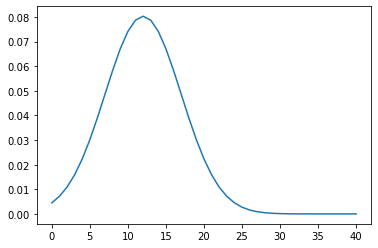

In [69]:
plt.plot(tau_rev)

In [32]:
# stack data matrices
u = np.zeros((s,t,p))
d = np.zeros((s,t))

for count,state in enumerate(states):
    
    n = get_state_pop(pops,state)
    state_data = get_state_data(data,state)
    u_tmp, _ = clean_npis(state_data,tf)
    d_tmp = clean_deaths(state_data,tf)
    
    # form data matrices
    #X_tmp = u[0:(t-1),]
    #X_tmp = u[0:t,]
    u[count,:,:] = u_tmp[0:t,]
    #d[count,] = d_tmp[0:t]
    d[count,] = d_tmp[lag:(t+lag)]
    
    #if count == 0:
    #    X = X_tmp
    #else:
    #    X = np.concatenate([X,X_tmp])

In [137]:
num_states = 3 #51
starts = np.zeros(num_states)
n = np.zeros(num_states)
days = np.zeros(num_states)

for count,state in enumerate(states[10:(num_states+10)]):
    
    n_tmp = get_state_pop(pops,state)
    n[count] = n_tmp
    
    state_data = get_state_data(data,state)
    u_tmp, _ = clean_npis(state_data,tf)
    d_tmp = clean_deaths(state_data,tf)
    
    start = np.min(np.where(d_tmp > 0))
    if start <= cutoff:
        start = 0
    else: 
        start = start - cutoff
    starts[count] = start
    days[count] = t-start
    
    if count == 0:  
        u = u_tmp[start:t,]
        d = d_tmp[start:t]
    else:
        u = np.concatenate([u,u_tmp[start:t,]])
        d = np.concatenate([d,d_tmp[start:t]])

In [139]:
print(np.shape(u));
print(np.shape(d));
ts = np.cumsum(np.concatenate([np.array([0]),days])); print(ts)

(182, 8)
(182,)
[  0.  69. 126. 182.]


In [140]:
sir_bhm_code = """
data {
  int<lower=1> p;         // number of NPIs
  int<lower=1> s;         // number of states
  array[s+1] int t;         // days
  array[t[s+1]] int d;    // deaths
  matrix[t[s+1],p] u;  // NPIs  
  array[s] int n;  // state populations
  
  int<lower=0> cutoff;  // cutoff of time to death
  vector<lower=0>[cutoff+1] tau_rev; // time to death distribution, reversed  
  
}
parameters {
  real<lower=0> beta0;                
  real<lower=0> beta_sd; // random effect sd       
  vector[s] beta_diff; // normalized state-level difference            
  
  simplex[p] rho; // global npi effects
  //vector[p] rho; // global npi effects
  
  //vector<lower=0>[p] rho_sd; // random effect sd
  //array[s] vector[p] rho_diff; // normalized state-level difference
  
  //real<lower=0> rho_scale;
  //real<lower=0,upper=1000> rho_scale;
  vector<lower=0>[p] rho_scale;
  //vector<lower=0,upper=0.2>[p] rho_scale;
  
  array[s] simplex[p] rho_s;
  //array[s] vector[p] rho_s;
  
  vector<lower=0>[s] kappa; // over-dispersion parameters
  
  real<lower=0> gamma;  
  vector[s] s0_tilde; 
  //vector[s] i0_tilde;
  real<lower=0> ifr;
}
transformed parameters {
  //array[s] vector[p] rho_s; // state-level npi effects
  
  vector[t[s+1]] beta; // betas
  matrix[t[s+1]+s,2] x;  // SIR state 
  vector<lower=0>[t[s+1]] nu;  // new infections
  vector<lower=0>[t[s+1]] death_par;  // death mean
  
  vector[s] beta0_s = beta0 + beta_sd * beta_diff;
  
  vector<lower=0,upper=1>[s] s0 = Phi(s0_tilde);  // initial susceptible
  //vector<lower=0,upper=1>[s] i0 = Phi(i0);  // initial infectious
  //vector<lower=0,upper=1>[s] i0 = 1 - s0;  // initial infectious  

  //real<lower=1.0/11.5,upper=1.0/5.5> gamma = 1/gamma_inv;
  
  for(state in 1:s){
    //rho_s[state] = rho + rho_sd .* rho_diff[state];
    
    beta[(t[state]+1):t[state+1]] = beta0_s[state] * (1 - u[(t[state]+1):t[state+1],1:p] * rho_s[state]);
    x[t[state]+1,1] = s0[state];
    x[t[state]+1,2] = 1-s0[state];
    for(day in 1:(t[state+1]-t[state])){
      nu[t[state]+day] = beta[t[state]+day] * x[t[state]+day,1] * x[t[state]+day,2];
      x[t[state]+day+1,1] = x[t[state]+day,1] - nu[t[state]+day];
      x[t[state]+day+1,2] = x[t[state]+day,2]*(1-gamma) + nu[t[state]+day];
      if(day <= cutoff){
      death_par[t[state]+day] = sum(tau_rev[(cutoff-day+2):(cutoff+1)] .* nu[(t[state]+1):(t[state]+day)]);
      death_par[t[state]+day] += sum(tau_rev[1:(cutoff-day+1)])*(1-s0[state]);
      death_par[t[state]+day] *= ifr*n[state];
      }else{
      death_par[t[state]+day] = n[state]*ifr*sum(tau_rev .* nu[(t[state]+day-cutoff):(t[state]+day)]);
      }
    }
  }  
}
model {
  //target += normal_lpdf(beta0 | 3 * gamma, 1 * gamma);
  
  //target += uniform_lpdf(beta_sd | 0.01, 0.2);
  
  //target += dirichlet_lpdf(rho | rep_vector(1, p));
  
  //target += uniform_lpdf(rho_scale | 0, 1000);
  //target += gamma_lpdf(rho_scale | 0.01, 0.01);
  //target += uniform_lpdf(rho_scale | 0, 0.2);
  
  target += normal_lpdf(s0_tilde | 0, 1);
  
  target += normal_lpdf(ifr | 0.0068, 0.0007); // meyerowitz-katz and merone ifr
  target += normal_lpdf(gamma | 0.15, 0.05);
  
  target += normal_lpdf(beta_diff | 0, 1);       // prior log-density  

  for(state in 1:s){
      target += neg_binomial_2_lpmf(d[(t[state]+1):t[state+1]] | death_par[(t[state]+1):t[state+1]], kappa[state]); // likelihood on deaths
  
      //target += dirichlet_lpdf(rho_s[state] | rho_scale * rho);
      target += dirichlet_lpdf(rho_s[state] | rho_scale .* rho);
      //target += normal_lpdf(rho_s[state] | rho, rho_scale);
      
      //target += normal_lpdf(rho_diff[state] | 0, 1);       // prior log-density
  }
}
"""

sir_bhm_data = {"p" : p, "s" : num_states, "t" : ts.astype(int), 
            "d" : d.astype(int), "u" : u, "n" : n.astype(int),
            "cutoff" : cutoff, "tau_rev" : tau_rev
           }

In [141]:
posterior = stan.build(sir_bhm_code, data=sir_bhm_data)

Building...



Building: found in cache, done.Messages from stanc:


## One state (ohio)

In [826]:
t = 365 # days to model

tf = 731
s = len(states)

gamma = 0.15
lag = 28

cutoff = 40
tau_rev = np.flip(norm.pdf(np.arange(0,cutoff+1), 28, 3))
tau_rev = tau_rev/np.sum(tau_rev)

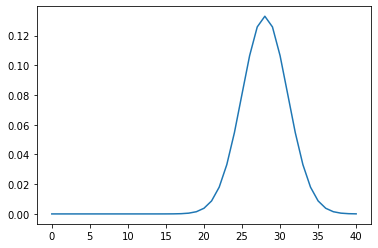

In [827]:
plt.plot(np.flip(tau_rev))

In [828]:
num_states = 1 #51
starts = np.zeros(num_states)
n = np.zeros(num_states)
days = np.zeros(num_states)

state = states[35]; print(state)
    
n = get_state_pop(pops,state)
    
state_data = get_state_data(data,state)
u, _ = clean_npis(state_data,tf)
d = clean_deaths(state_data,tf)
    
#start = np.min(np.where(d > 50))
start = np.min(np.where(d > 1))
if start <= cutoff:
    start = 0
else: 
    start = start - cutoff
days = t-start

d_full = d

#u = u[start:t,]
# remove int'l travel controls
u = u[start:t,[0,1,2,3,4,5,6,8,9,10,11]]
d = d[start:t]

p = np.shape(u)[1]

Ohio


In [829]:
start

36

In [830]:
print(np.shape(u));
print(np.shape(d));
#ts = np.cumsum(np.concatenate([np.array([0]),days])); print(ts)
ts = days; print(ts)
print(n)

(329, 11)
(329,)
329
[11594163.]


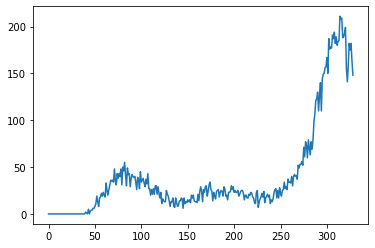

In [831]:
plt.plot(d)

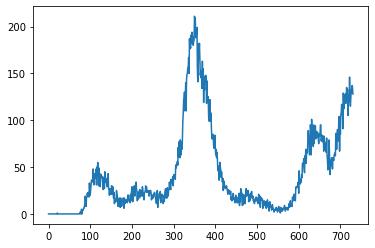

In [832]:
plt.plot(d_full)

## Multiplicative control model

In [633]:
sir_code = """
data {
  int<lower=1> p;         // number of NPIs
  int<lower=1> t;         // days
  array[t] int d;    // deaths
  matrix[t,p] u;  // NPIs  
  int<lower=1> n;  // state populations
  
  int<lower=0> cutoff;  // cutoff of time to death
  vector<lower=0>[cutoff+1] tau_rev; // time to death distribution, reversed  
  
}
parameters {
  real<lower=0> beta0;   
  //vector<lower=0>[t] beta;
  
  //vector<lower=0>[t] beta0t; // AR(1) process for beta0
  vector[t] beta_eps;
  
  real<lower=0> sigma; // beta_eps std dev
  //real<lower=0> c; // bias
  real<lower=0,upper=1> phi; //autocorrelation
  
  vector[p] rho; // npi effects
  
  //real<lower=0> kappa; // over-dispersion parameters
  
  real<lower=0> gamma;  
  real<lower=0> ifr;
  
  //real s0_tilde; 
  simplex[3] x0; // initial state
}
transformed parameters {
  //matrix[t+1,2] x;  // SIR state 
  vector<lower=0,upper=1>[t+1] sus; // proportion susceptible
  vector<lower=0,upper=1>[t+1] inf; // proportion infected
  
  vector<lower=0,upper=1>[t] nu;  // new infections
  vector<lower=0>[t] death_par;  // death mean
  
  vector<lower=0>[t] beta;
  
  //real<lower=0,upper=1> s0 = 0.999 + 0.001 * Phi(s0_tilde);  // initial susceptible 
  
  //real log_beta0 = log(beta0);
  //vector[t] log_beta = log_beta0 + u * rho + beta_eps;
  //vector<lower=0>[t] beta = exp(log_beta);
  
  //x[1,1] = s0;
  //x[1,2] = 1-s0;
  //sus[1] = x0[1];
  //inf[1] = x0[2];  
  sus[1] = 0.0001 * x0[1] + 0.9999;
  inf[1] = 0.0001 * x0[2];
  //sus[1] = s0;
  //inf[1] = 1-s0;
  for(day in 1:t){
    beta[day] = beta0 * prod(1 - rho' .* u[day]) + beta_eps[day];
  
    //nu[day] = beta[day] * x[day,1] * x[day,2];
    //x[day+1,1] = x[day,1] - nu[day];
    //x[day+1,2] = x[day,2]*(1-gamma) + nu[day];
    nu[day] = beta[day] * sus[day] * inf[day];
    sus[day+1] = sus[day] - nu[day];
    inf[day+1] = inf[day]*(1-gamma) + nu[day];
    if(day <= cutoff){
      death_par[day] = dot_product(tau_rev[(cutoff-day+2):(cutoff+1)], nu[1:day]);
      //death_par[day] = sum(tau_rev[(cutoff-day+2):(cutoff+1)] .* nu[1:day]);      
      death_par[day] += sum(tau_rev[1:(cutoff-day+1)]) * (1-sus[1]);
      death_par[day] *= ifr * n;
      //death_par[day] = n*ifr*(sum(tau_rev[(cutoff-day+2):(cutoff+1)] .* nu[1:day])+sum(tau_rev[1:(cutoff-day+1)])*(1-sus[1]));
    }else{
      death_par[day] = n * ifr * dot_product(tau_rev, nu[(day-cutoff):day]);
      //death_par[day] = n * ifr * sum(tau_rev .* nu[(day-cutoff):day]);
    }
  }
}  
model {
  //target += normal_lpdf(beta0 | 3 * gamma, 1 * gamma);
  target += normal_lpdf(beta0 | 3 * 0.15, 1 * 0.15);
  
  //target += normal_lpdf(beta0t[1] | 3 * gamma, 1 * gamma);  
  //target += normal_lpdf(beta0t[2:t] | c + phi * beta0t[1:(t-1)], sigma); // AR(1) model on betas
  //target += normal_lpdf(beta0t[2:t] | phi * beta0t[1:(t-1)], sigma); // AR(1) model on betas  
  //target += normal_lpdf(beta0t[2:t] | beta0t[1:(t-1)], sigma); // SRW model on betas   
  
  target += uniform_lpdf(phi | 0, 1);
  //target += normal_lpdf(beta_eps | 0, sigma);
  target += normal_lpdf(beta_eps[1] | 0, sigma);
  target += normal_lpdf(beta_eps[2:t] | phi * beta_eps[1:(t-1)], sigma); // AR(1) model on beta_eps

  //target += normal_lpdf(rho | 0, 1);
  target += uniform_lpdf(rho | 0, 1);
  
  target += dirichlet_lpdf(x0 | rep_vector(1,3));
  //target += normal_lpdf(s0_tilde | 0, 1);
  
  target += normal_lpdf(ifr | 0.0068, 0.0007); // meyerowitz-katz and merone ifr
  target += normal_lpdf(gamma | 0.15, 0.05);

  //target += neg_binomial_2_lpmf(d | death_par, kappa); // likelihood on deaths
  target += poisson_lpmf(d | death_par);
  
  target += -log(sigma);
  //target += -log(kappa);
  //increment_log_prob(-log(kappa)); // "Jeffreys" prior on scale parameter  
}
generated quantities {
    //array[t] int dhat = neg_binomial_2_rng(death_par, kappa);
    array[t] int dhat = poisson_rng(death_par);
}
"""

sir_data = {"p" : p, "t" : ts, 
            "d" : d.astype(int), "u" : u, "n" : int(n),
            "cutoff" : cutoff, "tau_rev" : tau_rev
           }

In [634]:
posterior = stan.build(sir_code, data=sir_data)

Building...



Building: 34.1s, done.Messages from stanc:


In [660]:
# prod model: (1-rho * u)
fit = posterior.sample(num_chains=2, num_samples=1000, num_warmup = 3000, save_warmup = False,
                       init=[{"beta0": 0.45, "beta_eps": np.zeros(ts), "gamma": 0.15,
                              "ifr": 0.0068, "alpha": 0.7, "rho": np.ones(p)/p, "sigma": 0.09},
                            {"beta0": 0.45, "beta_eps": np.zeros(ts), "gamma": 0.15,
                              "ifr": 0.0068, "alpha": 0.7, "rho": np.ones(p)/p, "sigma": 0.09}])

Sampling:   0%
Sampling:   0% (1/8000)
Sampling:   0% (2/8000)
Sampling:   1% (101/8000)
Sampling:   2% (200/8000)
Sampling:   4% (300/8000)
Sampling:   5% (400/8000)
Sampling:   6% (500/8000)
Sampling:   8% (600/8000)
Sampling:   9% (700/8000)
Sampling:  10% (800/8000)
Sampling:  11% (900/8000)
Sampling:  12% (1000/8000)
Sampling:  14% (1100/8000)
Sampling:  15% (1200/8000)
Sampling:  16% (1300/8000)
Sampling:  18% (1400/8000)
Sampling:  19% (1500/8000)
Sampling:  20% (1600/8000)
Sampling:  21% (1700/8000)
Sampling:  22% (1800/8000)
Sampling:  24% (1900/8000)
Sampling:  25% (2000/8000)
Sampling:  26% (2100/8000)
Sampling:  28% (2200/8000)
Sampling:  29% (2300/8000)
Sampling:  30% (2400/8000)
Sampling:  31% (2500/8000)
Sampling:  32% (2600/8000)
Sampling:  34% (2700/8000)
Sampling:  35% (2800/8000)
Sampling:  36% (2900/8000)
Sampling:  38% (3000/8000)
Sampling:  39% (3100/8000)
Sampling:  40% (3200/8000)
Sampling:  41% (3300/8000)
Sampling:  42% (3400/8000)
Sampling:  44% (3500/8000)
S

  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::log_prob: beta[1] is -90371.4, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_eowmjxar/model_l7dz7e3o.stan', line 42, column 2 to column 26)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::log_prob: beta[1] is -2581.79, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_eo

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::log_prob: nu[94] is -1.21261e-06, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_eowmjxar/model_l7dz7e3o.stan', line 39, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::lo

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::log_prob: nu[93] is -2.16869e-07, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_eowmjxar/model_l7dz7e3o.stan', line 39, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::lo

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::log_prob: nu[104] is -5.74178e-06, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_eowmjxar/model_l7dz7e3o.stan', line 39, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::l

...

  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::log_prob: nu[155] is -1.51722e-07, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_eowmjxar/model_l7dz7e3o.stan', line 39, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::log_prob: nu[93] is -2.707e-06, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpst

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::log_prob: nu[112] is -3.39169e-07, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_eowmjxar/model_l7dz7e3o.stan', line 39, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::l

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::log_prob: nu[163] is -5.28971e-07, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_eowmjxar/model_l7dz7e3o.stan', line 39, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::l

  Exception: model_l7dz7e3o_namespace::log_prob: nu[108] is -6.03908e-07, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_eowmjxar/model_l7dz7e3o.stan', line 39, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::log_prob: nu[108] is -3.48183e-06, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_eowmjxar/model_l7dz7e3o.stan', line 39, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this 

  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_l7dz7e3o_namespace::log_prob: nu[164] is -1.54325e-07, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_eowmjxar/model_l7dz7e3o.stan', line 39, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.


In [613]:
# mult model: log linear
fit = posterior.sample(num_chains=2, num_samples=1000, num_warmup = 1000, save_warmup = False,
                       init=[{"beta0": 0.45, "beta_eps": np.zeros(ts), "gamma": 0.15,
                              "ifr": 0.0068, "alpha": 0.7, "rho": np.zeros(p), "sigma": 0.09},
                            {"beta0": 0.45, "beta_eps": np.zeros(ts), "gamma": 0.15,
                              "ifr": 0.0068, "alpha": 0.7, "rho": np.zeros(p), "sigma": 0.09}])

Sampling:   0%
Sampling:   0% (1/4000)
Sampling:   0% (2/4000)
Sampling:   3% (101/4000)
Sampling:   5% (200/4000)
Sampling:   8% (300/4000)
Sampling:  10% (400/4000)
Sampling:  12% (500/4000)
Sampling:  15% (600/4000)
Sampling:  18% (700/4000)
Sampling:  20% (800/4000)
Sampling:  22% (900/4000)
Sampling:  25% (1000/4000)
Sampling:  28% (1100/4000)
Sampling:  30% (1200/4000)
Sampling:  32% (1300/4000)
Sampling:  35% (1400/4000)
Sampling:  38% (1500/4000)
Sampling:  40% (1600/4000)
Sampling:  42% (1700/4000)
Sampling:  45% (1800/4000)
Sampling:  48% (1901/4000)
Sampling:  50% (2001/4000)
Sampling:  50% (2002/4000)
Sampling:  53% (2101/4000)
Sampling:  55% (2200/4000)
Sampling:  58% (2300/4000)
Sampling:  60% (2400/4000)
Sampling:  62% (2500/4000)
Sampling:  65% (2600/4000)
Sampling:  68% (2700/4000)
Sampling:  70% (2800/4000)
Sampling:  72% (2900/4000)
Sampling:  75% (3000/4000)
Sampling:  78% (3100/4000)
Sampling:  80% (3200/4000)
Sampling:  82% (3300/4000)
Sampling:  85% (3400/4000)
S

  Exception: model_gzd3jqvd_namespace::log_prob: sus[3] is nan, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_4w1dilk4/model_gzd3jqvd.stan', line 36, column 2 to column 35)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_gzd3jqvd_namespace::log_prob: sus[3] is nan, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_4w1dilk4/model_gzd3jqvd.stan', line 36, column 2 to column 35)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often

## Additive control model

In [675]:
sir_code = """
data {
  int<lower=1> p;         // number of NPIs
  int<lower=1> t;         // days
  array[t] int d;    // deaths
  matrix[t,p] u;  // NPIs  
  int<lower=1> n;  // state populations
  
  int<lower=0> cutoff;  // cutoff of time to death
  vector<lower=0>[cutoff+1] tau_rev; // time to death distribution, reversed  
  
}
parameters {
  real<lower=0> beta0; 
  //real beta0;
  //real<lower=0,upper=1> beta0;
  //vector<lower=0>[t] beta;
  
  //vector<lower=0>[t] beta0t; // AR(1) process for beta0
  vector[t] beta_eps;
  //vector<lower=0>[t] beta_eps;
  //vector<lower=0,upper=1>[t] beta_eps;
  
  real<lower=0> sigma; // beta_eps std dev
  //real<lower=0> c; // bias
  real<lower=0,upper=1> phi; //autocorrelation
  
  simplex[p] rho; // relative npi effects
  real<lower=0,upper=1> alpha; // total effect
  
  //real<lower=0> kappa; // over-dispersion parameters
  
  real<lower=0> gamma;  
  //real<lower=0.05,upper=0.25> gamma;  
  real<lower=0,upper=1> ifr;
  
  //real s0_tilde; 
  simplex[3] x0; // initial state
}
transformed parameters {
  //matrix[t+1,2] x;  // SIR state 
  vector<lower=0,upper=1>[t+1] sus; // proportion susceptible
  vector<lower=0,upper=1>[t+1] inf; // proportion infected
  
  vector<lower=0,upper=1>[t] nu;  // new infections
  vector<lower=0>[t] death_par;  // death mean
  
  //real<lower=0,upper=1> s0 = 0.999 + 0.001 * Phi(s0_tilde);  // initial susceptible 
  
  //vector[t] beta = beta0 * (1 - alpha * u * rho);  
  //vector<lower=0>[t] beta = beta0 * (1 - alpha * u * rho) + beta_eps; 
  vector[t] beta = beta0 * (1 - alpha * u * rho) + beta_eps;   
  //vector[t] beta = beta0t .* (1 - alpha * u * rho);
  //vector[t] beta = beta0 * (1 - alpha * u * rho) .* beta_eps; 
  //vector[t] log_beta_eps = logit(beta_eps);
  
  //x[1,1] = s0;
  //x[1,2] = 1-s0;
  //sus[1] = x0[1];
  //inf[1] = x0[2];  
  sus[1] = 0.0001 * x0[1] + 0.9999;
  inf[1] = 0.0001 * x0[2];
  //sus[1] = s0;
  //inf[1] = 1-s0;
  for(day in 1:t){
    //nu[day] = beta[day] * x[day,1] * x[day,2];
    //x[day+1,1] = x[day,1] - nu[day];
    //x[day+1,2] = x[day,2]*(1-gamma) + nu[day];
    nu[day] = beta[day] * sus[day] * inf[day];
    sus[day+1] = sus[day] - nu[day];
    inf[day+1] = inf[day]*(1-gamma) + nu[day];
    if(day <= cutoff){
      death_par[day] = dot_product(tau_rev[(cutoff-day+2):(cutoff+1)], nu[1:day]);
      //death_par[day] = sum(tau_rev[(cutoff-day+2):(cutoff+1)] .* nu[1:day]);      
      death_par[day] += sum(tau_rev[1:(cutoff-day+1)]) * (1-sus[1]);
      death_par[day] *= ifr * n;
      //death_par[day] = n*ifr*(sum(tau_rev[(cutoff-day+2):(cutoff+1)] .* nu[1:day])+sum(tau_rev[1:(cutoff-day+1)])*(1-sus[1]));
    }else{
      death_par[day] = n * ifr * dot_product(tau_rev, nu[(day-cutoff):day]);
      //death_par[day] = n * ifr * sum(tau_rev .* nu[(day-cutoff):day]);
    }
  }
}  
model {
  //target += normal_lpdf(beta0 | 3 * gamma, 1 * gamma);
  target += normal_lpdf(beta0 | 3 * 0.15, 1 * 0.15);
  //target += uniform_lpdf(beta0 | 0, 1);
  //target += normal_lpdf(beta | beta0 * (1 - alpha * u * rho), sigma);
  
  //target += normal_lpdf(beta0t[1] | 3 * gamma, 1 * gamma);  
  //target += normal_lpdf(beta0t[2:t] | c + phi * beta0t[1:(t-1)], sigma); // AR(1) model on betas
  //target += normal_lpdf(beta0t[2:t] | phi * beta0t[1:(t-1)], sigma); // AR(1) model on betas  
  //target += normal_lpdf(beta0t[2:t] | beta0t[1:(t-1)], sigma); // SRW model on betas   
  
  target += uniform_lpdf(phi | 0, 1);
  //target += normal_lpdf(beta_eps | 0, sigma);
  //target += normal_lpdf(beta_eps[1] | 0, gamma);
  target += normal_lpdf(beta_eps[1] | 0, sigma);
  target += normal_lpdf(beta_eps[2:t] | phi * beta_eps[1:(t-1)], sigma); // AR(1) model on beta_eps
  //target += normal_lpdf(log_beta_eps[1] | 0, sigma);
  //target += normal_lpdf(log_beta_eps[2:t] | phi * log_beta_eps[1:(t-1)], sigma); // AR(1) model on log_beta_eps
 
  target += uniform_lpdf(alpha | 0, 1);
  target += dirichlet_lpdf(rho | rep_vector(1, p));
  
  target += dirichlet_lpdf(x0 | rep_vector(1,3));
  //target += normal_lpdf(s0_tilde | 0, 1);
  
  target += normal_lpdf(ifr | 0.0068, 0.0007); // meyerowitz-katz and merone ifr
  target += normal_lpdf(gamma | 0.15, 0.05);
  //target += uniform_lpdf(gamma | 0.05, 0.25);

  //target += neg_binomial_2_lpmf(d | death_par, kappa); // likelihood on deaths
  target += poisson_lpmf(d | death_par);
  
  target += -log(sigma);
  //target += uniform_lpdf(sigma | 0, 0.1);
  //target += -log(kappa);
  //increment_log_prob(-log(kappa)); // "Jeffreys" prior on scale parameter  
}
generated quantities {
    //array[t] int dhat = neg_binomial_2_rng(death_par, kappa);
    array[t] int dhat = poisson_rng(death_par);
}
"""

sir_data = {"p" : p, "t" : ts, 
            "d" : d.astype(int), "u" : u, "n" : int(n),
            "cutoff" : cutoff, "tau_rev" : tau_rev
           }

In [676]:
posterior = stan.build(sir_code, data=sir_data)

Building...



Building: 33.5s, done.Messages from stanc:


In [677]:
fit = posterior.sample(num_chains=3, num_samples=2000, num_warmup = 3000, save_warmup = False,
                       init=[{"beta0": 0.45, "beta_eps": np.zeros(ts), "gamma": 0.15,
                              "ifr": 0.0068, "alpha": 0.7, "rho": np.ones(p)/p, "sigma": 0.09},
                            {"beta0": 0.45, "beta_eps": np.zeros(ts), "gamma": 0.15,
                              "ifr": 0.0068, "alpha": 0.7, "rho": np.ones(p)/p, "sigma": 0.09},
                            {"beta0": 0.45, "beta_eps": np.zeros(ts), "gamma": 0.15,
                              "ifr": 0.0068, "alpha": 0.7, "rho": np.ones(p)/p, "sigma": 0.09}])

Sampling:   0%
Sampling:   0% (1/15000)
Sampling:   0% (2/15000)
Sampling:   0% (3/15000)
Sampling:   1% (102/15000)
Sampling:   1% (201/15000)
Sampling:   2% (300/15000)
Sampling:   3% (400/15000)
Sampling:   3% (500/15000)
Sampling:   4% (600/15000)
Sampling:   5% (700/15000)
Sampling:   5% (800/15000)
Sampling:   6% (900/15000)
Sampling:   7% (1000/15000)
Sampling:   7% (1100/15000)
Sampling:   8% (1200/15000)
Sampling:   9% (1300/15000)
Sampling:   9% (1400/15000)
Sampling:  10% (1500/15000)
Sampling:  11% (1600/15000)
Sampling:  11% (1700/15000)
Sampling:  12% (1800/15000)
Sampling:  13% (1900/15000)
Sampling:  13% (2000/15000)
Sampling:  14% (2100/15000)
Sampling:  15% (2200/15000)
Sampling:  15% (2300/15000)
Sampling:  16% (2400/15000)
Sampling:  17% (2500/15000)
Sampling:  17% (2600/15000)
Sampling:  18% (2700/15000)
Sampling:  19% (2800/15000)
Sampling:  19% (2900/15000)
Sampling:  20% (3000/15000)
Sampling:  21% (3100/15000)
Sampling:  21% (3200/15000)
Sampling:  22% (3300/15

  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::log_prob: sus[3] is -3.56323e+07, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_bm17qma_/model_qvzwz7gn.stan', line 42, column 2 to column 35)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::log_prob: sus[5] is -7269.4, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_bm17qma_/model_qvzwz7gn.stan', line 42, column 2 to column 35)
  If this warning occurs sporadically, such a

  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::log_prob: nu[152] is -1.1494e-07, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_bm17qma_/model_qvzwz7gn.stan', line 45, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::log_prob: nu[148] is -3.16387e-06, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/http

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::log_prob: nu[96] is -1.95482e-06, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_bm17qma_/model_qvzwz7gn.stan', line 45, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::lo

  Exception: model_qvzwz7gn_namespace::log_prob: inf[2] is -5.42192e-06, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_bm17qma_/model_qvzwz7gn.stan', line 43, column 2 to column 35)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::log_prob: nu[37] is -9.66227e-12, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_bm17qma_/model_qvzwz7gn.stan', line 45, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this wa

...

  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::log_prob: nu[322] is -9.95955e-06, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_bm17qma_/model_qvzwz7gn.stan', line 45, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::log_prob: nu[304] is -1.55523e-05, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/htt

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::log_prob: nu[166] is -2.18798e-07, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_bm17qma_/model_qvzwz7gn.stan', line 45, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::l

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::log_prob: nu[83] is -4.12792e-07, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_bm17qma_/model_qvzwz7gn.stan', line 45, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::lo

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::log_prob: nu[95] is -2.176e-07, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_bm17qma_/model_qvzwz7gn.stan', line 45, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::log_

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::log_prob: nu[108] is -2.94925e-08, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_bm17qma_/model_qvzwz7gn.stan', line 45, column 2 to column 32)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_qvzwz7gn_namespace::l

## Plots

In [678]:
az.summary(fit)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0,0.518,0.062,0.416,0.639,0.003,0.002,402.0,984.0,1.01
beta_eps[0],0.002,0.028,-0.053,0.059,0.001,0.003,669.0,144.0,1.13
beta_eps[1],0.004,0.032,-0.058,0.071,0.001,0.003,482.0,213.0,1.10
beta_eps[2],0.006,0.033,-0.058,0.073,0.001,0.003,477.0,114.0,1.08
beta_eps[3],0.007,0.033,-0.059,0.074,0.002,0.003,371.0,93.0,1.07
...,...,...,...,...,...,...,...,...,...
dhat[324],167.890,14.221,140.000,193.000,0.196,0.139,5283.0,5527.0,1.00
dhat[325],166.228,13.746,141.000,192.000,0.182,0.129,5701.0,5400.0,1.00
dhat[326],164.608,13.728,141.000,191.000,0.188,0.133,5295.0,5690.0,1.00
dhat[327],163.534,14.152,139.000,191.000,0.241,0.171,3472.0,5521.0,1.00


(array([637.,  57.,  32.,  48., 139., 107.,  89.,  42.,  17.,   1.]),
 array([1.   , 1.138, 1.276, 1.414, 1.552, 1.69 , 1.828, 1.966, 2.104,
        2.242, 2.38 ]),
 <BarContainer object of 10 artists>)

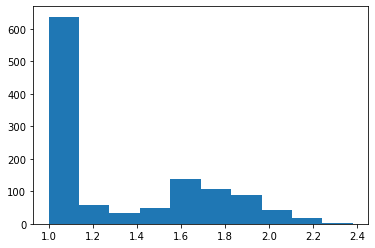

In [661]:
plt.hist(az.summary(fit)['r_hat'])

In [679]:
df = fit.to_frame();
df

parameters,lp__,accept_stat__,stepsize__,treedepth__,n_leapfrog__,divergent__,energy__,beta0,beta_eps.1,beta_eps.2,...,dhat.320,dhat.321,dhat.322,dhat.323,dhat.324,dhat.325,dhat.326,dhat.327,dhat.328,dhat.329
draws,,,,,,,,,,,,,,,,,,,,,
0,-25.445475,0.700425,0.001620,10.0,1023.0,0.0,207.975738,0.641331,-0.011766,0.007754,...,180.0,182.0,177.0,180.0,172.0,172.0,153.0,170.0,148.0,159.0
1,-513.438933,0.926809,0.001711,10.0,1023.0,0.0,706.362879,0.493151,0.086859,0.090581,...,193.0,176.0,197.0,161.0,144.0,167.0,157.0,157.0,165.0,142.0
2,-2.617867,0.956796,0.001756,10.0,1023.0,0.0,165.002946,0.465017,-0.001386,0.007166,...,191.0,166.0,164.0,189.0,172.0,191.0,168.0,176.0,163.0,169.0
3,-42.969573,0.813343,0.001620,10.0,1023.0,0.0,197.931489,0.694333,-0.007179,0.020173,...,179.0,173.0,169.0,165.0,155.0,148.0,173.0,158.0,147.0,145.0
4,-522.876857,0.831331,0.001711,10.0,1023.0,0.0,686.757495,0.502615,0.064286,0.128992,...,173.0,176.0,167.0,189.0,167.0,162.0,160.0,163.0,175.0,139.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,142.385271,0.923663,0.001711,10.0,1023.0,0.0,18.644120,0.576839,-0.006055,-0.009117,...,182.0,188.0,188.0,169.0,160.0,173.0,190.0,159.0,165.0,139.0
5996,-103.447471,0.994143,0.001756,10.0,1023.0,0.0,284.530741,0.519482,0.001087,0.009727,...,179.0,214.0,169.0,188.0,171.0,173.0,160.0,190.0,182.0,150.0
5997,126.840313,0.952118,0.001620,10.0,1023.0,0.0,47.390468,0.508377,0.005712,0.011172,...,188.0,192.0,179.0,184.0,182.0,156.0,179.0,158.0,164.0,141.0


In [692]:
# df.to_pickle("control_est_ohio_add_full.pkl")

In [681]:
# df = pd.read_pickle("control_est_ohio.pkl")

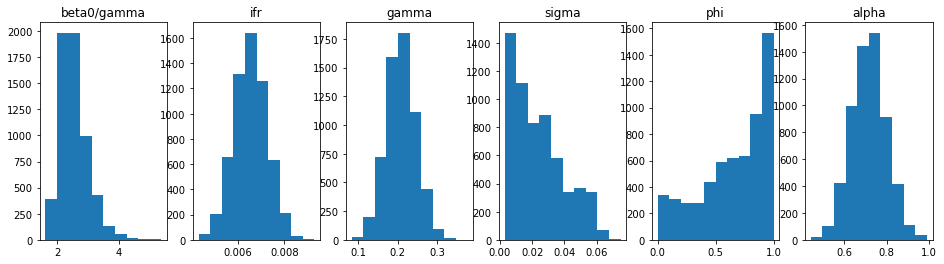

In [682]:
fs = 12  # fontsize
fig, axs = plt.subplots(nrows=1, ncols=6, figsize=(16,4))

axs[0].hist(df["beta0"]/df["gamma"]); axs[0].set_title('beta0/gamma'); 
# axs[0].hist(df["beta0t.1"]/gamma); axs[0].set_title('beta0/gamma'); 
axs[1].hist(df["ifr"]); axs[1].set_title('ifr');
axs[2].hist(df["gamma"]); axs[2].set_title('gamma');
#axs[3].hist(df["s0"]); axs[3].set_title('s0');
# axs[3].hist(df["x0.1"]); axs[3].set_title('x0.1');
# axs[4].hist(df["kappa"]); axs[4].set_title('kappa');
axs[3].hist(df["sigma"]); axs[3].set_title('sigma');
# axs[6].hist(df["c"]); axs[6].set_title('c');
axs[4].hist(df["phi"]); axs[4].set_title('phi');
axs[5].hist(df["alpha"]); axs[5].set_title('alpha');

plt.show()

(array([ 337.,  306.,  281.,  277.,  437.,  592.,  620.,  633.,  950.,
        1567.]),
 array([2.87184023e-04, 1.00172319e-01, 2.00057454e-01, 2.99942589e-01,
        3.99827724e-01, 4.99712859e-01, 5.99597994e-01, 6.99483129e-01,
        7.99368264e-01, 8.99253399e-01, 9.99138534e-01]),
 <BarContainer object of 10 artists>)

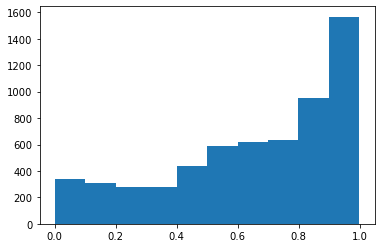

In [683]:
plt.hist(df["phi"])

(array([   4.,    5.,   14.,   52.,  177.,  388., 1037., 1751., 2009.,
         563.]),
 array([0.93611472, 0.9422844 , 0.94845407, 0.95462375, 0.96079343,
        0.96696311, 0.97313278, 0.97930246, 0.98547214, 0.99164181,
        0.99781149]),
 <BarContainer object of 10 artists>)

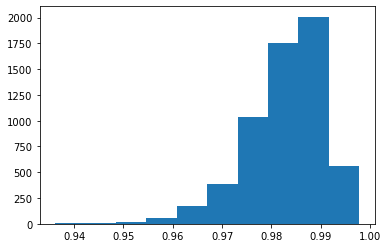

In [684]:
plt.hist(df["x0.1"])

In [685]:
np.mean(df["sigma"])

0.023999741350004357

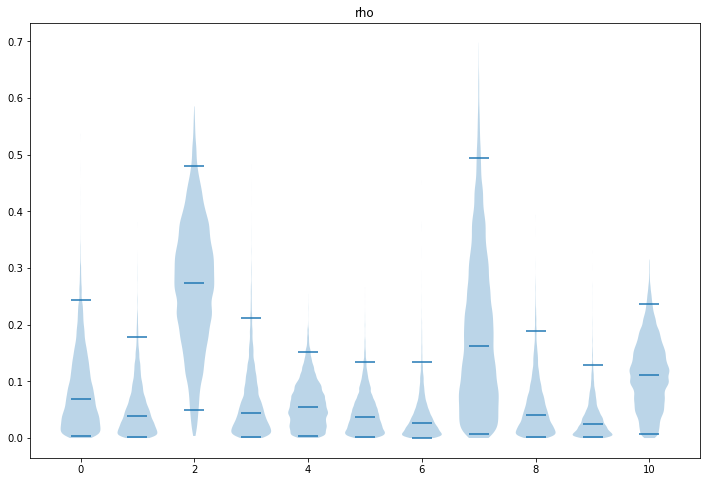

In [686]:
# violin plots
fs = 12  # fontsize
fig, ax = plt.subplots(figsize=(12,8))

ax.violinplot(dataset=[df["rho." + str(npi+1)] for npi in range(p)],
                     positions=np.arange(p), points=300, widths=0.7, vert=True,
                     showmeans=False, showextrema=False, showmedians=True,
                     quantiles=[[0.025, 0.975] for npi in range(p)], bw_method=0.1)
ax.set_title('rho', fontsize=fs)

#plt.savefig("beta_lmm_normal_scale_simplex_rho_s_violins.pdf")
plt.show()

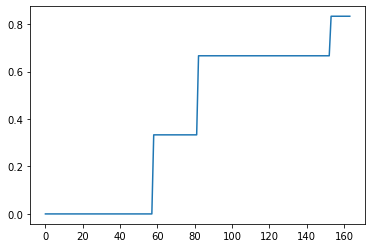

In [657]:
plt.plot(u[:,10])

Text(0.5, 1.0, 'nu')

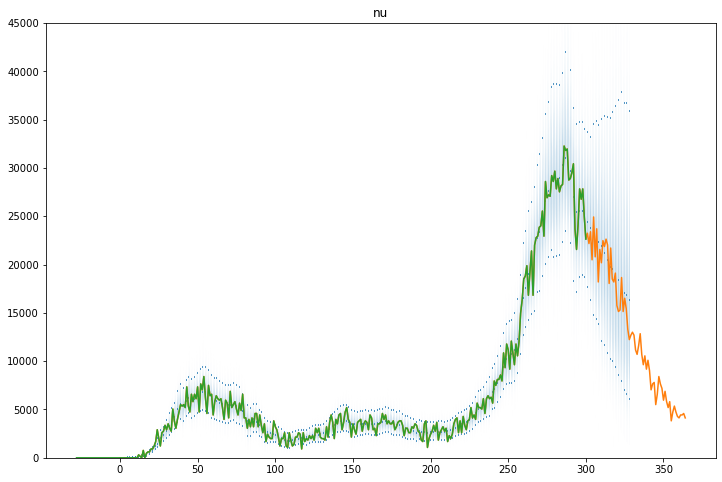

In [689]:
fs = 12  # fontsize
fig, ax = plt.subplots(figsize=(12,8))

ax.violinplot(dataset=[n*df["nu." + str(day+1)] for day in range(ts)],
                     positions=np.arange(ts), points=300, widths=0.7, vert=True,
                     showmeans=False, showextrema=False, showmedians=True,
                     quantiles=[[0.025, 0.975] for day in range(ts)], bw_method=0.1)
#ax.violinplot(dataset=[df["inf." + str(day+1)] for day in range(ts)],
#                     positions=np.arange(ts), points=300, widths=0.7, vert=True,
#                     showmeans=False, showextrema=False, showmedians=True,
#                     quantiles=[[0.025, 0.975] for day in range(ts)], bw_method=0.1)
ax.set_ylim([0,45000])
#ax.plot(range(-lag,t-lag,1),d_full[(lag):(t+lag)]/np.median(df['ifr']))
#ax.plot(range(-lag,t-lag,1),d_full[(lag):(t+lag)]/np.median(df['ifr']))
ax.plot(d_full[(lag+start):(t+start+lag)]/np.median(df['ifr']))
ax.plot(range(-lag,t-lag-start,1),d/np.median(df['ifr']))
#ax.plot(d[lag:]/100)
#ax.plot(d*5000)
ax.set_title('nu', fontsize=fs)

Text(0.5, 1.0, 'deaths')

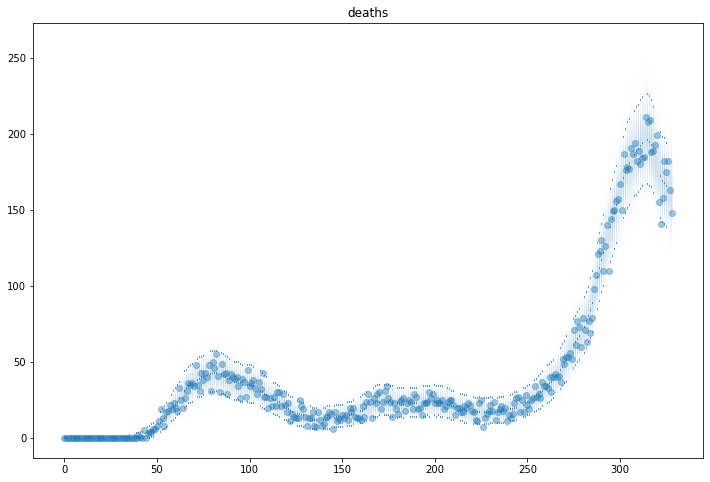

In [694]:
fs = 12  # fontsize
fig, ax = plt.subplots(figsize=(12,8))

ax.violinplot(dataset=[df["dhat." + str(day+1)] for day in range(ts)],
                     positions=np.arange(ts), points=300, widths=0.7, vert=True,
                     showmeans=False, showextrema=False, showmedians=True,
                     quantiles=[[0.025, 0.975] for day in range(ts)], bw_method=0.1)
#ax.violinplot(dataset=[df["inf." + str(day+1)] for day in range(ts)],
#                     positions=np.arange(ts), points=300, widths=0.7, vert=True,
#                     showmeans=False, showextrema=False, showmedians=True,
#                     quantiles=[[0.025, 0.975] for day in range(ts)], bw_method=0.1)
#ax.plot(d_full[(lag):(t+lag)])
ax.scatter(range(0,np.shape(d)[0],1),d, alpha = 0.4)
#ax.plot(d[lag:]/100)
#ax.plot(d*5000)
ax.set_title('deaths', fontsize=fs)

Text(0.5, 1.0, 'beta_eps')

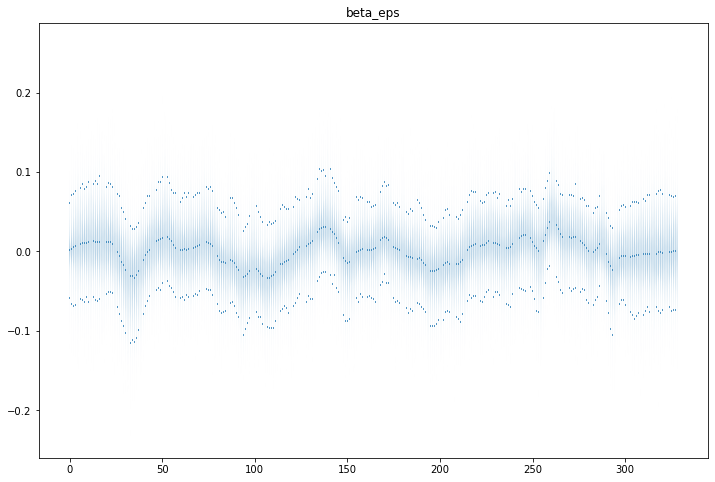

In [691]:
fs = 12  # fontsize
fig, ax = plt.subplots(figsize=(12,8))

ax.violinplot(dataset=[df["beta_eps." + str(day+1)] for day in range(ts)],
                     positions=np.arange(ts), points=300, widths=0.7, vert=True,
                     showmeans=False, showextrema=False, showmedians=True,
                     quantiles=[[0.025, 0.975] for day in range(ts)], bw_method=0.1)
#ax.violinplot(dataset=[df["inf." + str(day+1)] for day in range(ts)],
#                     positions=np.arange(ts), points=300, widths=0.7, vert=True,
#                     showmeans=False, showextrema=False, showmedians=True,
#                     quantiles=[[0.025, 0.975] for day in range(ts)], bw_method=0.1)
#ax.plot(d[lag:]/100)
#ax.plot(d*5000)
ax.set_title('beta_eps', fontsize=fs)

## Calculate costs and OC

In [843]:
# set time frame to look at
t0 = 275 - start # october 1, 2020
t1 = 305 - start # october 31, 2020
days = range(t0,t1,1)

In [844]:
len(days)

30

In [845]:
np.shape(u)

(329, 11)

In [846]:
# set cost vector
c = np.ones(p)/(10**6)

In [847]:
# calculate cost incurred by actual policy
cost = 0
for day in days:
    cost += np.mean(df["nu." + str(day)]) + np.dot(c,u[day,:])
    
print(cost)

0.03251085686470117


In [848]:
def generate_binary_strings(bit_count):
    binary_strings = []
    def genbin(n, bs=''):
        if len(bs) == 2*n:
            binary_strings.append(bs)           
        else:
            genbin(n, bs + '0 ')
            genbin(n, bs + '1 ')


    genbin(bit_count)
    return binary_strings

binstr = generate_binary_strings(p)

In [849]:
plans = np.zeros([2**p,p])
for i in range(2**p):
    plans[i,:] = [int(x) for x in binstr[i].split()]
    
print(plans)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 1. 0.]
 ...
 [1. 1. 1. ... 1. 0. 1.]
 [1. 1. 1. ... 1. 1. 0.]
 [1. 1. 1. ... 1. 1. 1.]]


In [850]:
def sir(gamma,beta0,alpha,rho,s0,i0,t,u):
    s = np.array([]); i = np.array([]); nu = np.array([])
    sj = s0; ij = i0;
    s = np.append(s,sj); i = np.append(i,ij)
    beta = beta0 * (1 - alpha * np.dot(rho,u))
    for j in range(t-1):
        nuj = beta*sj*ij
        sj = sj - nuj
        ij = ij*(1-gamma) + nuj
        s = np.append(s,sj); i = np.append(i,ij); nu = np.append(nu,nuj)
    
    return s, i, nu

In [851]:
[df["rho." + str(k+1)][10] for k in range(p)]

[0.04933290754836849,
 0.05899744460868433,
 0.3996905449715568,
 0.02578086132596256,
 0.08954893380476231,
 0.008121306618886546,
 0.026948708944788506,
 0.05626567330368489,
 0.12224840781290347,
 0.044498825767790746,
 0.11856638529261138]

In [852]:
df["sus." + str(t0)][10]

0.9359329436066165

In [856]:
n_days = t1-t0
# n_samples = np.shape(df)[0]
n_samples = 100

In [857]:
# calculate myopic OC
costs = np.zeros(2**p)

for i in range(2**p):
    print(i)
    u_prop = plans[i,:]
    
    #nus = np.zeros([n_samples,n_days-1])
    nu_cost = 0
    # evolve SIR model under this plan for each posterior sample
    for j in range(n_samples):
        _,_, nu = sir(gamma = df["gamma"][5999-j],
                            beta0 = df["beta0"][5999-j],
                            alpha = df["alpha"][5999-j],
                            rho = [df["rho." + str(k+1)][5999-j] for k in range(p)],
                            s0 = df["sus." + str(t0)][5999-j],
                            i0 = df["inf." + str(t0)][5999-j],
                            t = n_days+1,
                            u = u_prop)
    nu_cost += np.sum(nu)/n_samples
    
    # calculate cost 
    costs[i] = nu_cost + n_days*np.dot(c,u_prop)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

1861
1862
1863
1864
1865
1866
1867
1868
1869
1870
1871
1872
1873
1874
1875
1876
1877
1878
1879
1880
1881
1882
1883
1884
1885
1886
1887
1888
1889
1890
1891
1892
1893
1894
1895
1896
1897
1898
1899
1900
1901
1902
1903
1904
1905
1906
1907
1908
1909
1910
1911
1912
1913
1914
1915
1916
1917
1918
1919
1920
1921
1922
1923
1924
1925
1926
1927
1928
1929
1930
1931
1932
1933
1934
1935
1936
1937
1938
1939
1940
1941
1942
1943
1944
1945
1946
1947
1948
1949
1950
1951
1952
1953
1954
1955
1956
1957
1958
1959
1960
1961
1962
1963
1964
1965
1966
1967
1968
1969
1970
1971
1972
1973
1974
1975
1976
1977
1978
1979
1980
1981
1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025
2026
2027
2028
2029
2030
2031
2032
2033
2034
2035
2036
2037
2038
2039
2040
2041
2042
2043
2044
2045
2046
2047


In [858]:
np.argmin(costs)

1345

In [859]:
np.min(costs)

0.00017844319025222123

In [860]:
np.max(costs)

0.00805855269412445

In [861]:
costs[np.argmin(costs)]

0.00017844319025222123

In [862]:
uhat = plans[np.argmin(costs),:]
print(uhat)

[1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1.]


In [863]:
# plot trajectory under myopic OC
nus = np.zeros([n_samples,n_days])
# evolve SIR model under this plan for each posterior sample
for j in range(n_samples):
    _,_, nus[j,:] = sir(gamma = df["gamma"][5999-j],
                        beta0 = df["beta0"][5999-j],
                        alpha = df["alpha"][5999-j],
                        rho = [df["rho." + str(k+1)][5999-j] for k in range(p)],
                        s0 = df["sus." + str(t0)][5999-j],
                        i0 = df["inf." + str(t0)][5999-j],
                        t = n_days+1,
                        u = uhat)

Text(0.5, 1.0, 'nu')

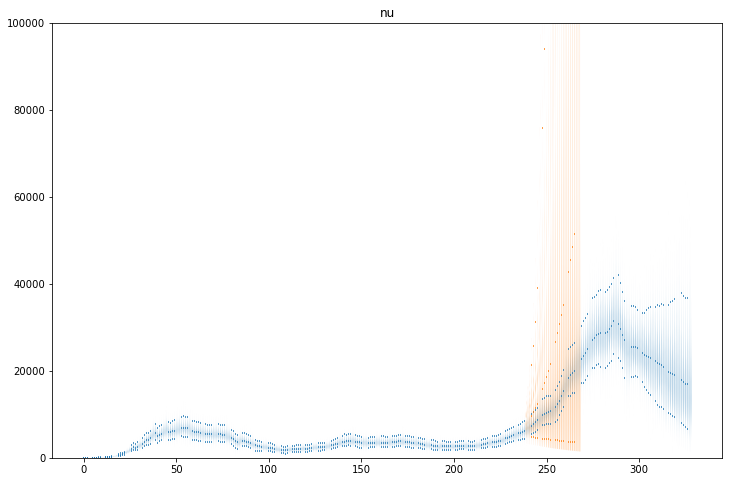

In [865]:
fs = 12  # fontsize
fig, ax = plt.subplots(figsize=(12,8))

ax.violinplot(dataset=[n*df["nu." + str(day+1)] for day in range(ts)],
                     positions=np.arange(ts), points=300, widths=0.7, vert=True,
                     showmeans=False, showextrema=False, showmedians=True,
                     quantiles=[[0.025, 0.975] for day in range(ts)], bw_method=0.1)
ax.violinplot(dataset=n*nus,
                     positions=days, points=300, widths=0.7, vert=True,
                     showmeans=False, showextrema=False, showmedians=True,
                     quantiles=[[0.025, 0.975] for day in days], bw_method=0.1)
#ax.violinplot(dataset=[df["inf." + str(day+1)] for day in range(ts)],
#                     positions=np.arange(ts), points=300, widths=0.7, vert=True,
#                     showmeans=False, showextrema=False, showmedians=True,
#                     quantiles=[[0.025, 0.975] for day in range(ts)], bw_method=0.1)
ax.set_ylim([0,100000])
#ax.plot(range(-lag,t-lag,1),d_full[(lag):(t+lag)]/np.median(df['ifr']))
#ax.plot(range(-lag,t-lag,1),d_full[(lag):(t+lag)]/np.median(df['ifr']))
#ax.plot(d_full[(lag+start):(t+start+lag)]/np.median(df['ifr']))
#ax.plot(range(-lag,t-lag-start,1),d/np.median(df['ifr']))
#ax.plot(d[lag:]/100)
#ax.plot(d*5000)
ax.set_title('nu', fontsize=fs)

# BHM on betas: linear regression

In [6]:
t = 366 # days to model
lag = 28
window = 14
ifr = 0.007
gamma = 0.15

trunc = 10 #10
tf = 731
p = 12
s = len(states)

In [7]:
"""
num_states = 3
X = np.zeros((num_states,t-1,p))
y = np.zeros((num_states,t-1))

# stack data matrices
for count,state in enumerate(states[33:(33+num_states)]):
    
    n = get_state_pop(pops,state)
    state_data = get_state_data(data,state)
    u, _ = clean_npis(state_data,tf)
    d = clean_deaths(state_data,tf)
    
    # get trajectory of infections
    i = np.convolve(d/ifr,np.ones(window)/(window),mode='same')[(lag-1):(t+lag-1)]
    
    # estimate betas
    betas, _ = beta_solve(gamma,i,t,n)
    
    # run linear regression and calculate R^2
    X_tmp = u[0:(t-1),]
    y_tmp = betas
    #inds = np.logical_and(0<betas,betas<trunc*gamma)
    #y_tmp = betas[inds]
    #X_tmp = X_tmp[inds,]
    #state_id_tmp = count*np.ones(np.shape(y_tmp)[0])
    
    X[count,:,:] = X_tmp
    y[count,:] = y_tmp
"""    

"\nnum_states = 3\nX = np.zeros((num_states,t-1,p))\ny = np.zeros((num_states,t-1))\n\n# stack data matrices\nfor count,state in enumerate(states[33:(33+num_states)]):\n    \n    n = get_state_pop(pops,state)\n    state_data = get_state_data(data,state)\n    u, _ = clean_npis(state_data,tf)\n    d = clean_deaths(state_data,tf)\n    \n    # get trajectory of infections\n    i = np.convolve(d/ifr,np.ones(window)/(window),mode='same')[(lag-1):(t+lag-1)]\n    \n    # estimate betas\n    betas, _ = beta_solve(gamma,i,t,n)\n    \n    # run linear regression and calculate R^2\n    X_tmp = u[0:(t-1),]\n    y_tmp = betas\n    #inds = np.logical_and(0<betas,betas<trunc*gamma)\n    #y_tmp = betas[inds]\n    #X_tmp = X_tmp[inds,]\n    #state_id_tmp = count*np.ones(np.shape(y_tmp)[0])\n    \n    X[count,:,:] = X_tmp\n    y[count,:] = y_tmp\n"

In [47]:
num_states = 51

# stack data matrices
# for count,state in enumerate(states[31:(31+num_states)]):
for count,state in enumerate(states):
    
    n = get_state_pop(pops,state)
    state_data = get_state_data(data,state)
    u, _ = clean_npis(state_data,tf)
    d = clean_deaths(state_data,tf)
    
    # get trajectory of infections
    i = np.convolve(d/ifr,np.ones(window)/(window),mode='same')[(lag-1):(t+lag-1)]
    
    # estimate betas
    betas, _ = beta_solve(gamma,i,t,n)
    
    # run linear regression and calculate R^2
    X_tmp = u[0:(t-1),]
    inds = np.logical_and(0<betas,betas<trunc*gamma)
    y_tmp = betas[inds]
    X_tmp = X_tmp[inds,]
    
    if count == 0:
        X = X_tmp
        y = y_tmp
        days = np.array(sum(inds)).reshape((1,1))
    else:
        X = np.concatenate([X,X_tmp])
        y = np.concatenate([y,y_tmp])
        days = np.concatenate([days,np.array(sum(inds)).reshape((1,1))])

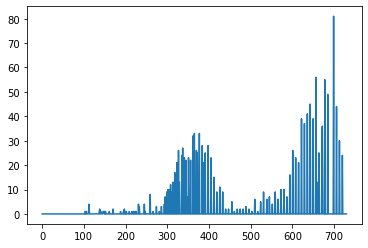

In [48]:
plt.plot(d)

In [49]:
print(np.shape(X));
print(np.shape(y));
ts = np.cumsum(np.concatenate([np.array(0).reshape((1,1)),days])); print(ts)

(15637, 12)
(15637,)
[    0   252   558   870  1183  1518  1834  2141  2440  2743  3073  3395
  3637  3946  4242  4562  4884  5199  5521  5845  6161  6480  6758  7078
  7394  7707  8024  8300  8613  8905  9196  9495  9818 10131 10447 10766
 11088 11406 11723 12044 12360 12681 12985 13303 13623 13929 14250 14438
 14772 15091 15389 15637]


In [50]:
print((sum(np.isnan(y))));
print((sum(sum(np.isnan(X)))));

0
0


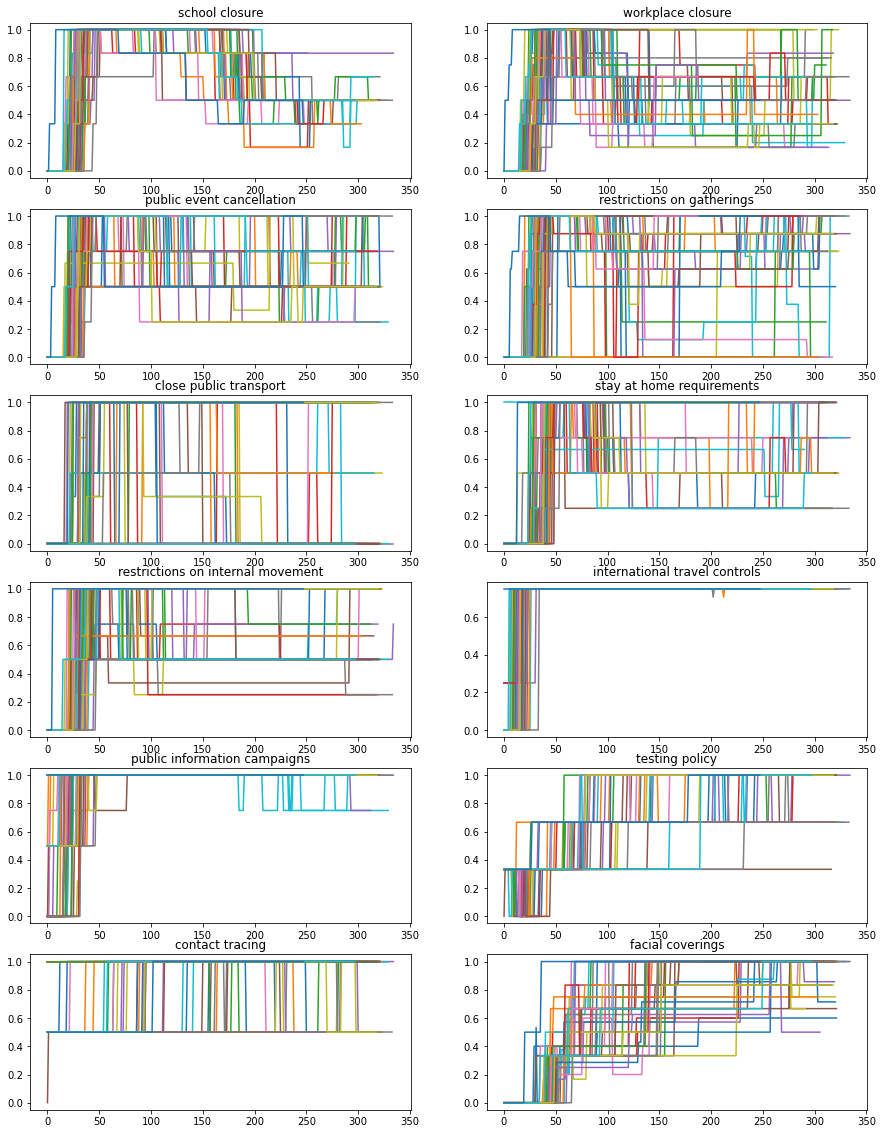

In [79]:
fig, axs = plt.subplots(nrows=6, ncols=2, figsize=(15,20))

for j in range(s):
    axs[0,0].plot(X[ts[j]:ts[j+1],0])
    axs[0,0].set_title("school closure")
    
for j in range(s):
    axs[0,1].plot(X[ts[j]:ts[j+1],1])
    axs[0,1].set_title("workplace closure")
    
for j in range(s):
    axs[1,0].plot(X[ts[j]:ts[j+1],2])
    axs[1,0].set_title("public event cancellation")
    
for j in range(s):
    axs[1,1].plot(X[ts[j]:ts[j+1],3])
    axs[1,1].set_title("restrictions on gatherings")
    
for j in range(s):
    axs[2,0].plot(X[ts[j]:ts[j+1],4])
    axs[2,0].set_title("close public transport")   

for j in range(s):
    axs[2,1].plot(X[ts[j]:ts[j+1],5])
    axs[2,1].set_title("stay at home requirements")
    
for j in range(s):
    axs[3,0].plot(X[ts[j]:ts[j+1],6])
    axs[3,0].set_title("restrictions on internal movement")   

for j in range(s):
    axs[3,1].plot(X[ts[j]:ts[j+1],7])
    axs[3,1].set_title("international travel controls")  

for j in range(s):
    axs[4,0].plot(X[ts[j]:ts[j+1],8])
    axs[4,0].set_title("public information campaigns")   

for j in range(s):
    axs[4,1].plot(X[ts[j]:ts[j+1],9])
    axs[4,1].set_title("testing policy")  

for j in range(s):
    axs[5,0].plot(X[ts[j]:ts[j+1],10])
    axs[5,0].set_title("contact tracing")   

for j in range(s):
    axs[5,1].plot(X[ts[j]:ts[j+1],11])
    axs[5,1].set_title("facial coverings")     
    
#plt.savefig("npi_variation.pdf")

In [ ]:
"""

bhm_code = 
#""
data {
  int<lower=1> p;         // number of NPIs
  int<lower=1> s;         // number of states
  vector<lower=1> t;         // number of days
  array[s] vector[t] y;    // betas
  array[s] matrix[t,p] X;  // NPIs  
  
  real<lower=0> gamma;
}
parameters {
  real<lower=0> beta0;                // population treatment effect
  real<lower=0> beta_sd;      // standard deviation in treatment effects
  vector[s] beta_diff;          // unscaled deviation from mu by school  
  
  vector[p] rho;                // population treatment effect  
  //vector<lower=0,upper=1>[p] rho;                // population treatment effect
  vector<lower=0>[p] rho_sd;      // standard deviation in treatment effects
  array[s] vector[p] rho_diff;          // unscaled deviation in rho by state 
  
  vector<lower=0>[s] sigma;
}
transformed parameters {
  vector[s] beta0_state = beta0 + beta_sd * beta_diff;
  
  array[s] vector[p] rho_state;
  array[s] vector[t] beta_state;
  
  for(state in 1:s){
      rho_state[state] = rho + rho_sd .* rho_diff[state];
      
      beta_state[state] = beta0_state[state] - X[state] * rho_state[state];       
      
      //for(day in 1:t){
      //    beta_state[state,day] = beta0_state[state] - rho_state[state] .* X[state,day];      
      //}
  }
}
model {
  target += normal_lpdf(beta0 | 2 * gamma, 0.5 * gamma);
  //target += dirichlet_lpdf(rho | rep_vector(1, p));

  for(state in 1:s){
      target += normal_lpdf(beta_diff[state] | 0, 1);       // prior log-density
      target += normal_lpdf(rho_diff[state] | 0, 1);       // prior log-density  
      
      target += normal_lpdf(y[state] | beta_state[state], sigma[state]); // log-likelihood  
  }
}
#""

bhm_data = {"p" : p, "s" : num_states, "t" : t-1, "y" : y_sub, "X" : X_sub, "gamma" : gamma}

"""

## Additive model

In [81]:
bhm_code = """
data {
  int<lower=1> p;         // number of NPIs
  int<lower=1> s;         // number of states
  //int<lower=1> t;         // number of days
  array[s+1] int t;
  //array[s] vector[t] y;    // betas
  vector[t[s+1]] y;    // betas
  //array[s] matrix[t,p] X;  // NPIs  
  //array[t[s+1]] vector[p] X;  // NPIs  
  matrix[t[s+1],p] X;  // NPIs  
  
  //real<lower=0> gamma;
}
parameters {
  real<lower=0> beta0;                
  real<lower=0> beta_sd;      
  vector[s] beta_diff;            
  
  simplex[p] rho;
  //vector[p] rho;
  
  real<lower=0,upper=1> alpha; // total effect 
  //real<lower=0> alpha_sd; 
  //vector[s] alpha_diff;
  
  real<lower=0> alpha_scale; 
  vector<lower=0,upper=1>[s] alpha_s;  
  
  real<lower=0> rho_scale;
  //real<lower=0,upper=1000> rho_scale;
  //vector<lower=0,upper=0.2>[p] rho_scale;
  //vector<lower=0>[p] rho_sd;  
  
  //vector<lower=0>[p] rho_sd;
  //array[s] vector[p] rho_diff;
  
  array[s] simplex[p] rho_s;
  //array[s] vector[p] rho_s;
  
  vector<lower=0>[s] sigma;
  //real<lower=0> sigma;
}
transformed parameters {
  vector<lower=0>[s] beta0_s = beta0 + beta_sd * beta_diff;
  //vector<lower=0,upper=1>[s] alpha_s = alpha + alpha_sd * alpha_diff;  
  
  //array[s] vector[p] rho_s = 
}
model {
  //target += normal_lpdf(beta0 | 3 * gamma, 1 * gamma);
  target += normal_lpdf(beta0 | 3 * 0.15, 1 * 0.15);
  
  //target += uniform_lpdf(sigma | 0.05, 0.5);
  //target += uniform_lpdf(beta_sd | 0.01, 0.2);
  
  target += dirichlet_lpdf(rho | rep_vector(1, p));
  
  //target += uniform_lpdf(rho_scale | 0, 1000);
  //target += gamma_lpdf(rho_scale | 0.01, 0.01);
  //target += uniform_lpdf(rho_scale | 0, 0.2);
  
  target += uniform_lpdf(alpha | 0, 1);
  
  target += normal_lpdf(beta_diff | 0, 1);       // prior log-density
  //target += normal_lpdf(alpha_diff | 0, 1);  
  
  target += -log(sigma);
  target += -log(rho_scale);
  target += -log(beta_sd);
  target += -log(alpha_scale);

  for(state in 1:s){
      target += dirichlet_lpdf(rho_s[state] | rho_scale * rho);
      //target += dirichlet_lpdf(rho_s[state] | rho_scale .* rho);
      //target += normal_lpdf(rho_s[state] | rho, rho_sd);
      
      //target += normal_lpdf(beta_diff[state] | 0, 1);       // prior log-density
      //target += normal_lpdf(alpha_diff[state] | 0, 1);
      
      target += beta_lpdf(alpha_s[state] | alpha_scale * alpha, alpha_scale * (1-alpha));
      
      target += normal_lpdf(y[(t[state]+1):t[state+1]] | beta0_s[state] * (1 - alpha_s[state] * X[(t[state]+1):t[state+1],1:p] * rho_s[state]), sigma[state]);    
  
      //target += normal_lpdf(y[state] | beta0_s[state] * (1 - X[state] * rho_s[state]), sigma[state]);
      //target += normal_lpdf(y[state] | (beta0 + beta_sd * beta_diff[state]) * (1 - X[state] * rho_s[state]), sigma);
      //target += normal_lpdf(y[(t[state]+1):t[state+1]] | beta0_s[state] * (1 - alpha_s[state] * X[(t[state]+1):t[state+1],1:p] * rho), sigma[state]);    
  }
}
"""

bhm_data = {"p" : p, "s" : num_states, "t" : ts, #"t" : t-1, 
            "y" : y, "X" : X} #, "gamma" : gamma}

## Multiplicative model

In [ ]:
bhm_code = """
data {
  int<lower=1> p;         // number of NPIs
  int<lower=1> s;         // number of states
  //int<lower=1> t;         // number of days
  array[s+1] int t;
  //array[s] vector[t] y;    // betas
  vector[t[s+1]] y;    // betas
  //array[s] matrix[t,p] X;  // NPIs  
  //array[t[s+1]] vector[p] X;  // NPIs  
  matrix[t[s+1],p] X;  // NPIs  
  
  //real<lower=0> gamma;
}
parameters {
  real<lower=0> beta0;                
  real<lower=0> beta_sd;      
  vector[s] beta_diff;            
  
  vector[p] rho;

  //real<lower=0> rho_scale;
  //real<lower=0,upper=1000> rho_scale;
  //vector<lower=0,upper=0.2>[p] rho_scale;
  //vector<lower=0>[p] rho_sd;  
  
  vector<lower=0>[p] rho_sd;
  array[s] vector[p] rho_diff;
  
  //array[s] simplex[p] rho_s;
  //array[s] vector[p] rho_s;
  
  vector<lower=0>[s] sigma;
  //real<lower=0> sigma;
}
transformed parameters {
  vector<lower=0>[s] beta0_s = beta0 + beta_sd * beta_diff;
  //vector<lower=0,upper=1>[s] alpha_s = alpha + alpha_sd * alpha_diff;  
  
  array[s] vector[p] rho_s = rho + rho_sd * rho_diff;
}
model {
  //target += normal_lpdf(beta0 | 3 * gamma, 1 * gamma);
  //target += normal_lpdf(beta0 | 3 * 0.15, 1 * 0.15);
  
  //target += uniform_lpdf(sigma | 0.05, 0.5);
  //target += uniform_lpdf(beta_sd | 0.01, 0.2);
  
  //target += dirichlet_lpdf(rho | rep_vector(1, p));
  //target += normal_lpdf(rho | 0, );
  
  //target += uniform_lpdf(rho_scale | 0, 1000);
  //target += gamma_lpdf(rho_scale | 0.01, 0.01);
  //target += uniform_lpdf(rho_scale | 0, 0.2);
  
  target += normal_lpdf(beta_diff | 0, 1);       // prior log-density 
  
  target += -log(sigma);
  target += -sum(log(rho_sd));
  target += -log(beta_sd);

  for(state in 1:s){
      //target += normal_lpdf(rho_s[state] | rho, rho_sd);
      target += normal_lpdf(rho_diff[state] | 0, 1);
      
      //target += normal_lpdf(beta_diff[state] | 0, 1);       // prior log-density
      
      target += normal_lpdf(log(y[(t[state]+1):t[state+1]]) | beta0_s[state] + X[(t[state]+1):t[state+1],1:p] * rho_s[state], sigma[state]);   
  }
}
"""

bhm_data = {"p" : p, "s" : num_states, "t" : ts, #"t" : t-1, 
            "y" : y, "X" : X} #, "gamma" : gamma}

In [82]:
posterior = stan.build(bhm_code, data=bhm_data)

Building...



Building: 32.9s, done.

## Fit the model

In [83]:
fit = posterior.sample(num_chains=2, num_samples=500)

Sampling:   0%
Sampling:   0% (1/3000)
Sampling:   0% (2/3000)
Sampling:   3% (101/3000)
Sampling:   7% (200/3000)
Sampling:  10% (300/3000)
Sampling:  13% (400/3000)
Sampling:  17% (500/3000)
Sampling:  20% (600/3000)
Sampling:  23% (700/3000)
Sampling:  27% (800/3000)
Sampling:  30% (900/3000)
Sampling:  33% (1000/3000)
Sampling:  37% (1100/3000)
Sampling:  40% (1200/3000)
Sampling:  43% (1300/3000)
Sampling:  47% (1400/3000)
Sampling:  50% (1500/3000)
Sampling:  50% (1501/3000)
Sampling:  53% (1600/3000)
Sampling:  57% (1700/3000)
Sampling:  60% (1800/3000)
Sampling:  63% (1900/3000)
Sampling:  67% (2000/3000)
Sampling:  70% (2100/3000)
Sampling:  73% (2200/3000)
Sampling:  77% (2300/3000)
Sampling:  80% (2400/3000)
Sampling:  83% (2500/3000)
Sampling:  83% (2501/3000)
Sampling:  87% (2600/3000)
Sampling:  90% (2700/3000)
Sampling:  93% (2800/3000)
Sampling:  97% (2900/3000)
Sampling: 100% (3000/3000)
Sampling: 100% (3000/3000), done.
Messages received during sampling:
  Gradient ev

  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_plb5umdy_namespace::log_prob: beta0_s[8] is -0.011583, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_gjpnmu28/model_plb5umdy.stan', line 45, column 2 to column 59)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_plb5umdy_namespace::log_prob: beta0_s[2] is -0.0830351, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/ht

  Exception: model_plb5umdy_namespace::log_prob: beta0_s[3] is -0.0134204, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_gjpnmu28/model_plb5umdy.stan', line 45, column 2 to column 59)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_plb5umdy_namespace::log_prob: beta0_s[20] is -0.0062154, but must be greater than or equal to 0.000000 (in '/var/folders/02/7bf4kg8x2n9gn1rnlkmg0s_00000gp/T/httpstan_gjpnmu28/model_plb5umdy.stan', line 45, column 2 to column 59)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if th

In [84]:
az.summary(fit)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0,0.403,0.012,0.382,0.427,0.001,0.001,140.0,218.0,1.01
beta_sd,0.079,0.010,0.062,0.097,0.001,0.000,248.0,525.0,1.00
beta_diff[0],-0.027,0.578,-1.169,1.001,0.022,0.023,725.0,397.0,1.00
beta_diff[1],-0.129,0.427,-0.902,0.705,0.017,0.013,606.0,662.0,1.00
beta_diff[2],-0.585,0.318,-1.143,0.016,0.014,0.010,538.0,754.0,1.00
...,...,...,...,...,...,...,...,...,...
beta0_s[46],0.307,0.032,0.253,0.373,0.001,0.001,846.0,733.0,1.00
beta0_s[47],0.284,0.014,0.258,0.308,0.000,0.000,874.0,700.0,1.01
beta0_s[48],0.409,0.018,0.376,0.440,0.001,0.000,952.0,768.0,1.01
beta0_s[49],0.405,0.037,0.335,0.475,0.001,0.001,896.0,700.0,1.00


In [85]:
az.summary(fit["rho_scale"])

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
x,21.776,6.071,11.975,33.434,0.645,0.457,78.0,21.0,NaN


In [86]:
df = fit.to_frame()  # pandas `DataFrame, requires pandas

In [87]:
df

parameters,lp__,accept_stat__,stepsize__,treedepth__,n_leapfrog__,divergent__,energy__,beta0,beta_sd,beta_diff.1,...,beta0_s.42,beta0_s.43,beta0_s.44,beta0_s.45,beta0_s.46,beta0_s.47,beta0_s.48,beta0_s.49,beta0_s.50,beta0_s.51
draws,,,,,,,,,,,,,,,,,,,,,
0,13660.434666,0.991732,0.029597,9.0,511.0,0.0,-13323.136859,0.416905,0.088555,0.312181,...,0.246484,0.498769,0.444022,0.364044,0.417558,0.319046,0.292877,0.397683,0.487607,0.529862
1,13548.233280,0.814760,0.013764,8.0,255.0,0.0,-13167.647098,0.398880,0.064911,-0.103035,...,0.223676,0.471340,0.416029,0.379088,0.409829,0.298381,0.307349,0.417886,0.403872,0.299956
2,13664.766780,0.988182,0.029597,8.0,511.0,0.0,-13313.671482,0.423568,0.062406,-1.212167,...,0.284939,0.473840,0.435676,0.403563,0.404269,0.324308,0.282548,0.424580,0.380302,0.497719
3,13514.353437,0.951997,0.013764,8.0,255.0,0.0,-13146.341789,0.392309,0.073437,-0.270303,...,0.211478,0.442539,0.448670,0.313319,0.406077,0.276593,0.314101,0.422111,0.357581,0.331811
4,13697.928697,0.903776,0.029597,9.0,511.0,0.0,-13319.803999,0.416436,0.061686,0.439738,...,0.251430,0.434721,0.433771,0.363858,0.417671,0.296097,0.289103,0.437542,0.455510,0.482871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,13544.513406,0.978728,0.013764,8.0,255.0,0.0,-13160.649723,0.397772,0.069539,-0.348076,...,0.292834,0.513547,0.448502,0.382946,0.380063,0.372360,0.286042,0.399146,0.398680,0.325711
996,13672.450671,0.957629,0.029597,8.0,255.0,0.0,-13336.693900,0.416757,0.086652,0.165847,...,0.227981,0.481221,0.429169,0.405570,0.372830,0.271545,0.310850,0.412238,0.401969,0.502738
997,13581.324224,0.995022,0.013764,8.0,255.0,0.0,-13199.462180,0.391054,0.078490,1.165282,...,0.234603,0.435537,0.430690,0.364978,0.398057,0.253633,0.279380,0.427574,0.497394,0.615437


In [87]:
#df.to_pickle("beta_lmm_normal_scale_no_simplex.pkl")
#df.to_pickle("beta_lmm_latest.pkl")

In [569]:
#df = pd.read_pickle("beta_lmm_normal_scale_simplex_rho_s.pkl")

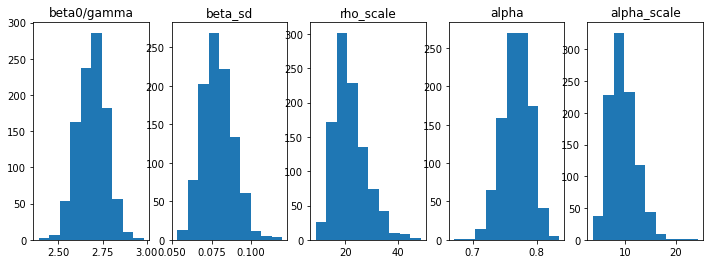

In [88]:
fs = 12  # fontsize
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(12,4))

# plt.hist(df["beta0"]); plt.title('beta0'); plt.show();
# axs[0].hist(df["beta0"]); axs[0].set_title('beta0'); #plt.show();
axs[0].hist(df["beta0"]/gamma); axs[0].set_title('beta0/gamma'); #plt.show();
#plt.hist(df["beta_sd"]); plt.title('beta_sd'); plt.show();
axs[1].hist(df["beta_sd"]); axs[1].set_title('beta_sd');

#plt.hist(df["rho_scale"]);
axs[2].hist(df["rho_scale"]); axs[2].set_title('rho_scale')
#plt.boxplot([df["rho_scale." + str(npi+1)] for npi in range(p)]);  
#plt.title('rho_scale'); plt.show();

# axs[2].violinplot(dataset=[df["rho_scale." + str(npi+1)] for npi in range(p)],
#                      positions=np.arange(p), points=300, widths=0.7, vert=True,
#                      showmeans=False, showextrema=False, showmedians=True,
#                      quantiles=[[0.025, 0.975] for npi in range(p)], bw_method=0.1)
# #axs[2].set_ylim([0,40])
# axs[2].set_title('rho_scale', fontsize=fs)

# axs[2].violinplot(dataset=[df["rho_sd." + str(npi+1)] for npi in range(p)],
#                      positions=np.arange(p), points=300, widths=0.7, vert=True,
#                      showmeans=False, showextrema=False, showmedians=True,
#                      quantiles=[[0.025, 0.975] for npi in range(p)], bw_method=0.1)
# #axs[2].set_ylim([0,40])
# axs[2].set_title('rho_sd', fontsize=fs)

axs[3].hist(df["alpha"]); axs[3].set_title('alpha');
# axs[4].hist(df["alpha_sd"]); axs[4].set_title('alpha_sd');
axs[4].hist(df["alpha_scale"]); axs[4].set_title('alpha_scale');

#plt.hist(df["sigma"]); plt.show();
#plt.boxplot([df["sigma.1"],df["sigma.2"],df["sigma.3"],df["sigma.4"],df["sigma.5"]]); plt.show()
# plt.boxplot([df["sigma." + str(state+1)] for state in range(num_states)]); 
# plt.title('sigma'); plt.show()

# plt.boxplot([df["rho." + str(npi+1)] for npi in range(p)]);  
# plt.title('rho'); plt.show();

#plt.savefig("beta_lmm_normal_scale_simplex_rho_s_hist.pdf")
plt.show()

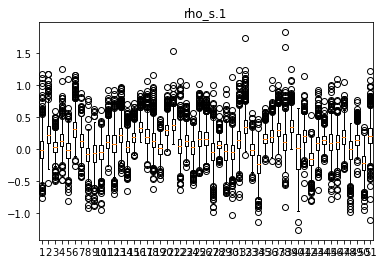

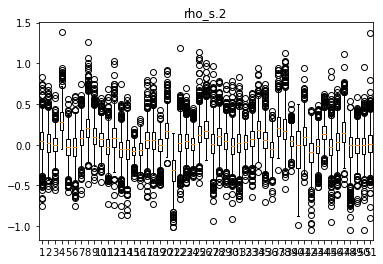

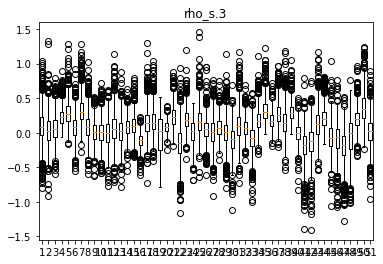

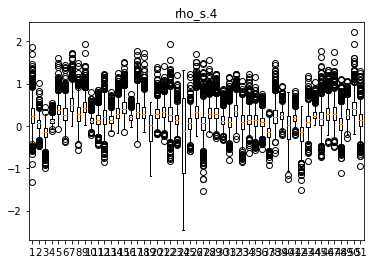

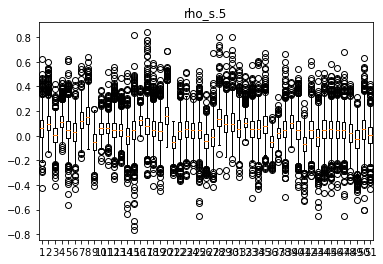

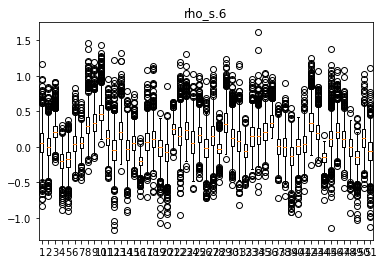

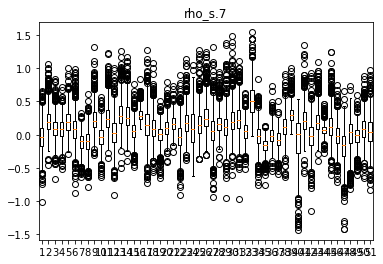

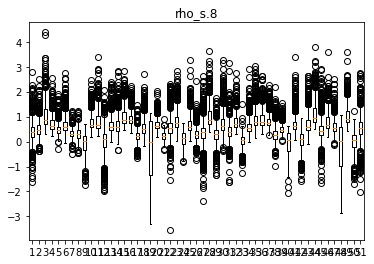

In [22]:
plt.boxplot([df["rho_s." + str(state+1) +".1"] for state in range(num_states)]); 
plt.title('rho_s.1'); plt.show()

plt.boxplot([df["rho_s." + str(state+1) +".2"] for state in range(num_states)]); 
plt.title('rho_s.2'); plt.show()

plt.boxplot([df["rho_s." + str(state+1) +".3"] for state in range(num_states)]); 
plt.title('rho_s.3'); plt.show()

plt.boxplot([df["rho_s." + str(state+1) +".4"] for state in range(num_states)]); 
plt.title('rho_s.4'); plt.show()

plt.boxplot([df["rho_s." + str(state+1) +".5"] for state in range(num_states)]); 
plt.title('rho_s.5'); plt.show()

plt.boxplot([df["rho_s." + str(state+1) +".6"] for state in range(num_states)]); 
plt.title('rho_s.6'); plt.show()

plt.boxplot([df["rho_s." + str(state+1) +".7"] for state in range(num_states)]); 
plt.title('rho_s.7'); plt.show()

plt.boxplot([df["rho_s." + str(state+1) +".8"] for state in range(num_states)]); 
plt.title('rho_s.8'); plt.show()

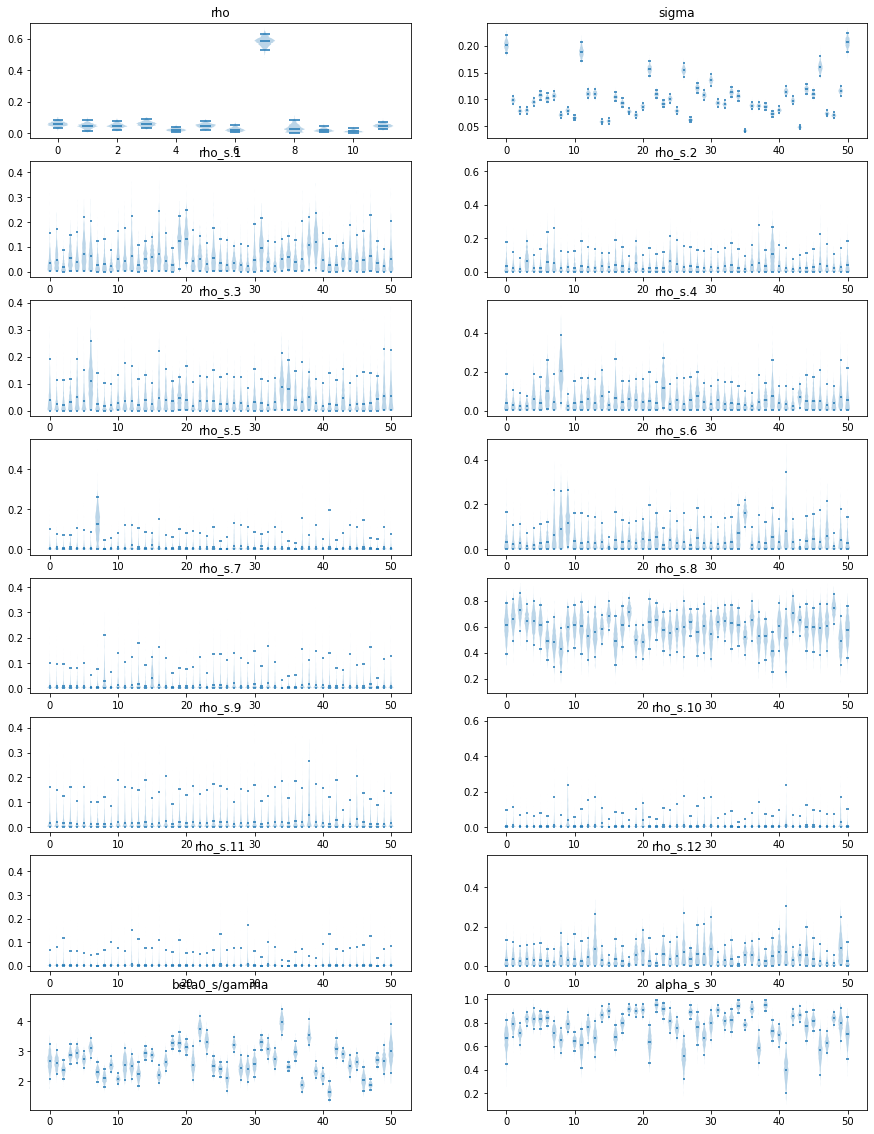

In [90]:
# violin plots
fs = 12  # fontsize
fig, axs = plt.subplots(nrows=8, ncols=2, figsize=(15,20))
# fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15,9))

axs[0, 0].violinplot(dataset=[df["rho." + str(npi+1)] for npi in range(p)],
                     positions=np.arange(p), points=300, widths=0.7, vert=True,
                     showmeans=False, showextrema=False, showmedians=True,
                     quantiles=[[0.025, 0.975] for npi in range(p)], bw_method=0.1)
axs[0, 0].set_title('rho', fontsize=fs)

# axs[0, 1].violinplot(dataset=[df["rho_scale." + str(npi+1)] for npi in range(p)],
#                      positions=np.arange(p), points=300, widths=0.7, vert=True,
#                      showmeans=False, showextrema=False, showmedians=True,
#                      quantiles=[[0.025, 0.975] for npi in range(p)], bw_method=0.1)
# axs[0, 1].set_title('rho_scale', fontsize=fs)

axs[0, 1].violinplot(dataset=[df["sigma." + str(state+1)] for state in range(num_states)],
                     positions=np.arange(num_states), points=300, widths=0.7, vert=True,
                     showmeans=False, showextrema=False, showmedians=True,
                     quantiles=[[0.025, 0.975] for npi in range(num_states)], bw_method=0.1)
axs[0, 1].set_title('sigma', fontsize=fs)

for col in range(6):
    axs[col+1, 0].violinplot(dataset=[df["rho_s." + str(state+1) +"."+str(2*col+1)] for state in range(num_states)],
                         positions=np.arange(num_states), points=300, widths=0.7, vert=True,
                         showmeans=False, showextrema=False, showmedians=True,
                         quantiles=[[0.025, 0.975] for npi in range(num_states)], bw_method=0.1)
    axs[col+1, 0].set_title('rho_s.'+str(2*col+1), fontsize=fs)

    axs[col+1, 1].violinplot(dataset=[df["rho_s." + str(state+1) +"."+str(2*col+2)] for state in range(num_states)],
                         positions=np.arange(num_states), points=300, widths=0.7, vert=True,
                         showmeans=False, showextrema=False, showmedians=True,
                         quantiles=[[0.025, 0.975] for npi in range(num_states)], bw_method=0.1)
    axs[col+1, 1].set_title('rho_s.'+str(2*col+2), fontsize=fs)
    
axs[7, 0].violinplot(dataset=[df["beta0_s." + str(state+1)]/gamma for state in range(num_states)],
                    positions=np.arange(num_states), points=300, widths=0.7, vert=True,
                    showmeans=False, showextrema=False, showmedians=True,
                    quantiles=[[0.025, 0.975] for npi in range(num_states)], bw_method=0.1)
axs[7, 0].set_title('beta0_s/gamma', fontsize=fs)     
    
axs[7, 1].violinplot(dataset=[df["alpha_s." + str(state+1)] for state in range(num_states)],
                    positions=np.arange(num_states), points=300, widths=0.7, vert=True,
                    showmeans=False, showextrema=False, showmedians=True,
                    quantiles=[[0.025, 0.975] for npi in range(num_states)], bw_method=0.1)
axs[7, 1].set_title('alpha_s', fontsize=fs)    

# for ax in axs.flat:
#     #ax.set_yticklabels([])
#     ax.set_yticklabels(np.arange(p))

#fig.suptitle("Parameter posteriors")
#fig.subplots_adjust(hspace=0.3)

#plt.savefig("beta_lmm_normal_scale_simplex_rho_s_violins.pdf")
plt.show()

<AxesSubplot:>

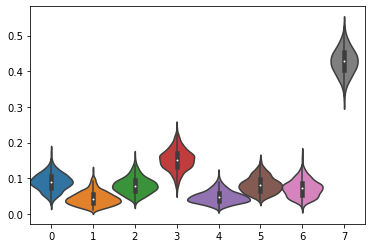

In [67]:
import seaborn as sns
#ax = sns.violinplot(x=, y="total_bill", data=tips)
sns.violinplot(data=[df["rho." + str(npi+1)] for npi in range(p)], width=1.5)

In [476]:
for npi in range(p):
    for state in range(num_states):
        if state == 0:
            u = np.sum(X[ts[state]:ts[state+1],npi]).reshape((1,))
        else:
            u = np.concatenate([u,np.sum(X[ts[state]:ts[state+1],npi]).reshape((1,))])
    print("npi " + str(npi+1));print(u)

npi 1
[200.66666667 198.5        214.         220.         268.66666667
 171.66666667 210.         188.         212.16666667 211.16666667
 214.16666667 143.5        200.         165.33333333 225.83333333
 221.66666667 212.83333333 226.16666667 220.33333333 216.5
 218.83333333 176.33333333 229.         213.16666667 208.66666667
 213.33333333 158.33333333 217.33333333 194.         174.16666667
 199.16666667 216.66666667 231.5        188.66666667 221.83333333
 233.33333333 204.16666667 211.33333333 212.66666667 236.5
 219.5        185.16666667 211.5        206.5        209.5
 221.33333333 115.5        213.         210.5        216.66666667
 163.33333333]
npi 2
[ 79.33333333 134.5        268.5        208.75       171.83333333
 180.83333333 204.66666667 202.66666667 285.         164.6
 195.         147.         196.75       153.66666667 133.5
 144.16666667 123.66666667 149.16666667 274.         200.83333333
 169.33333333 165.33333333 160.33333333 151.66666667  89.
 172.75       106.66666667

# Look at state-level fits

In [585]:
t = 366 # days to model
lag = 28
window = 14
ifr = 0.007
gamma = 0.15

trunc = 5
tf = 731
p = 8
s = len(states)

In [586]:
states[35]

'Ohio'

In [591]:
# for count,state in enumerate(states[35]):
state = states[35]    
    
n = get_state_pop(pops,state)
state_data = get_state_data(data,state)
u_tmp, _ = clean_npis(state_data,tf)
d_tmp = clean_deaths(state_data,tf)

i = np.convolve(d/ifr,np.ones(window)/(window),mode='same')[(lag-1):(t+lag-1)]
    
# form data matrices
#X_tmp = u[0:(t-1),]
#X_tmp = u[0:t,]
u = u_tmp[0:t,]
#d[count,] = d_tmp[0:t]
d = d_tmp[lag:(t+lag)]
    
#if count == 0:
#    X = X_tmp
#else:
#    X = np.concatenate([X,X_tmp])

In [597]:
np.shape(u)

(366, 8)

In [607]:
len(d)

366

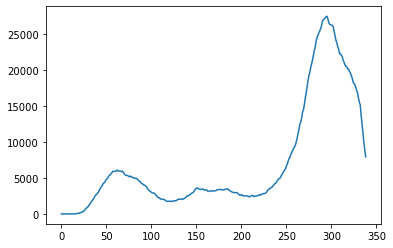

In [592]:
plt.plot(i)

In [602]:
start = np.max(np.where(i == 0)) + 1; start

15

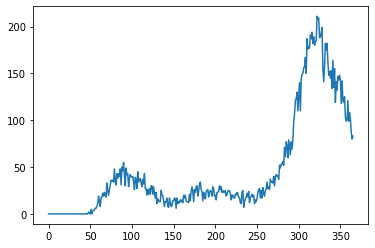

In [590]:
plt.plot(d)

In [593]:
def sir_beta(gamma,i0,t,n,betas,s0):
    s = np.array([]); i = np.array([]); nu = np.array([])
    sj = s0; ij = i0;
    s = np.append(s,sj); i = np.append(i,ij)
    for j in range(t-1):
        betaj = betas[j]
        nuj = betaj*sj*ij/n
        sj = sj - nuj
        ij = ij*(1-gamma) + nuj
        s = np.append(s,sj); i = np.append(i,ij); nu = np.append(nu,nuj)
    
    return s, i, nu

In [595]:
df["rho_s.35.1"][100]

0.003460747211142495

In [596]:
df["beta_diff.35"]

draws
0       1.259935
1       1.961976
2       1.422411
3       2.188724
4       1.428429
          ...   
2995    1.415631
2996    1.471227
2997    0.719244
2998    1.428443
2999    1.385960
Name: beta_diff.35, Length: 3000, dtype: float64

In [628]:
s_mat = np.zeros((len(df),t-start))
i_mat = np.zeros((len(df),t-start))
nu_mat = np.zeros((len(df),t-start-1))
beta_mat = np.zeros((len(df),t))
rho_mat = np.zeros((len(df),p))
beta0_mat = np.zeros((len(df)))

for j in range(len(df)):
    rho = [df["rho_s.35." + str(npi+1)][j] for npi in range(p)]
    rho_mat[j,:] = rho
    
    beta0 = df["beta0"][j] + df["beta_sd"][j]*df["beta_diff.35"][j]
    beta0_mat[j] = beta0
    
    beta = beta0*(1 - np.matmul(u,rho))
    beta_mat[j,:] = beta
    
    s_mat[j,:], i_mat[j,:], nu_mat[j,:] = sir_beta(gamma=0.15,i0 = i[start],t = t-start,
                                                   n = n,betas = beta[(start):], s0 = n-i[start])

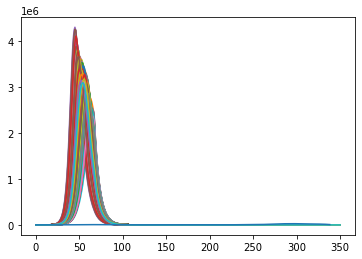

In [635]:
for j in range(len(df)):
    plt.plot(i_mat[j,])

plt.plot(i)
#plt.savefig("beta_lmm_normal_scale_rho_s_ohio.pdf")    
plt.show()

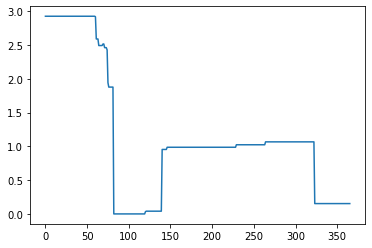

In [627]:
plt.plot(beta_mat[1,]/gamma)

# Linear regression on betas: no pooling/BHM

In [7]:
t = 401 # days to model
lag = 28
window = 14
ifr = 0.007
gamma = 0.15

trunc = 5 #10
tf = 731
p = 8
s = len(states)

In [8]:
# X = np.zeros((s,t-1,p))
# y = np.zeros((s,t-1))
X = np.zeros((s*(t-1),p))
y = np.zeros(s*(t-1))

# stack data matrices
for count,state in enumerate(states):
    
    n = get_state_pop(pops,state)
    state_data = get_state_data(data,state)
    u, _ = clean_npis(state_data,tf)
    d = clean_deaths(state_data,tf)
    
    # get trajectory of infections
    i = np.convolve(d/ifr,np.ones(window)/(window),mode='same')[(lag-1):(t+lag-1)]
    
    # estimate betas
    betas, _ = beta_solve(gamma,i,t,n)
    
    # run linear regression and calculate R^2
    X_tmp = u[0:(t-1),]
    inds = np.logical_and(0<betas,betas<trunc*gamma)
    y_tmp = betas[inds]
    X_tmp = X_tmp[inds,]
    #state_id_tmp = count*np.ones(np.shape(y_tmp)[0])    
    
    if count == 0:
        X = X_tmp
        y = y_tmp
        days = np.array(sum(inds)).reshape((1,1))
    else:
        X = np.concatenate([X,X_tmp])
        y = np.concatenate([y,y_tmp])
        days = np.concatenate([days,np.array(sum(inds)).reshape((1,1))])    

In [9]:
print(np.shape(y))
print(np.shape(X))

(17358,)
(17358, 8)


In [10]:
states[35]

'Ohio'

In [11]:
"""num_states = 51
X_tmp = X[0:num_states,:,:].reshape((num_states*(t-1),8))
y_tmp = y[0:num_states,:].reshape((num_states*(t-1)))"""

'num_states = 51\nX_tmp = X[0:num_states,:,:].reshape((num_states*(t-1),8))\ny_tmp = y[0:num_states,:].reshape((num_states*(t-1)))'

In [12]:
X_tmp = X; y_tmp = y

In [13]:
state_code = """
data {
  int<lower=1> p;         // number of NPIs
  int<lower=1> t;         // number of days
  vector[t] y;    // betas
  matrix[t,p] X;  // NPIs  
  
  real<lower=0> gamma;
}
parameters {
  real<lower=0> beta0;                
  //real<lower=0, upper = 5*gamma> beta0;
  //real beta0;
  
  //vector[p] rho;                 
  //vector<lower=0,upper=1>[p] rho;  
  simplex[p] rho;
  
  real<lower=0,upper=1> alpha;
  
  //real<lower=0, upper=0.1> sigma;
  real<lower=0> sigma; 
}
//transformed parameters {
//  vector[t] betas = beta0 - X * rho;
//}
model {
  target += normal_lpdf(beta0 | 3 * gamma, 1 * gamma);  
  //target += uniform_lpdf(beta0 | 0, 5 * gamma);
  //target += normal_lpdf(sigma | 0.1, 0.05);
  //target += uniform_lpdf(sigma | 0, 0.1);
  target += dirichlet_lpdf(rho | rep_vector(1, p));
  //target += normal_lpdf(rho | 0.1, 0.2);
  
  target += uniform_lpdf(alpha | 0, 1);
  
  target += normal_lpdf(y | beta0 * (1 - alpha * X * rho), sigma); // log-likelihood   
}
"""

#state_data = {"p" : p, "t" : t-1, "y" : y_sub, "X" : X_sub, "gamma" : gamma}
state_data = {"p" : 8, "t" : len(y_tmp), "y" : y_tmp, "X" : X_tmp, "gamma" : gamma}

In [14]:
posterior = stan.build(state_code, data=state_data)

Building...



Building: found in cache, done.Messages from stanc:


In [15]:
fit = posterior.sample(num_chains=2, num_samples=500)

Sampling:   0%
Sampling:   0% (1/4500)
Sampling:   0% (2/4500)
Sampling:   0% (3/4500)
Sampling:   2% (102/4500)
Sampling:   4% (202/4500)
Sampling:   7% (302/4500)
Sampling:   9% (402/4500)
Sampling:  11% (502/4500)
Sampling:  13% (601/4500)
Sampling:  16% (700/4500)
Sampling:  18% (800/4500)
Sampling:  20% (900/4500)
Sampling:  22% (1000/4500)
Sampling:  24% (1100/4500)
Sampling:  27% (1200/4500)
Sampling:  29% (1300/4500)
Sampling:  31% (1400/4500)
Sampling:  33% (1500/4500)
Sampling:  36% (1600/4500)
Sampling:  38% (1700/4500)
Sampling:  40% (1800/4500)
Sampling:  40% (1801/4500)
Sampling:  42% (1901/4500)
Sampling:  44% (2001/4500)
Sampling:  47% (2100/4500)
Sampling:  49% (2200/4500)
Sampling:  51% (2300/4500)
Sampling:  53% (2400/4500)
Sampling:  56% (2500/4500)
Sampling:  58% (2600/4500)
Sampling:  60% (2700/4500)
Sampling:  62% (2800/4500)
Sampling:  64% (2900/4500)
Sampling:  67% (3000/4500)
Sampling:  69% (3100/4500)
Sampling:  71% (3201/4500)
Sampling:  73% (3301/4500)
Samp

In [16]:
az.summary(fit)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0,0.388,0.004,0.381,0.395,0.000,0.0,1116.0,951.0,1.0
rho[0],0.040,0.015,0.011,0.066,0.000,0.0,849.0,568.0,1.0
rho[1],0.060,0.017,0.028,0.091,0.001,0.0,911.0,558.0,1.0
rho[2],0.029,0.015,0.001,0.054,0.000,0.0,980.0,620.0,1.0
rho[3],0.093,0.012,0.071,0.116,0.000,0.0,1169.0,786.0,1.0
rho[4],0.006,0.005,0.000,0.014,0.000,0.0,834.0,604.0,1.0
rho[5],0.072,0.013,0.048,0.097,0.000,0.0,1468.0,726.0,1.0
rho[6],0.017,0.010,0.000,0.034,0.000,0.0,1243.0,689.0,1.0
rho[7],0.684,0.016,0.656,0.715,0.000,0.0,1584.0,1377.0,1.0
alpha,0.635,0.006,0.624,0.646,0.000,0.0,1028.0,944.0,1.0


In [17]:
df = fit.to_frame()  # pandas `DataFrame, requires pandas

In [18]:
df

parameters,lp__,accept_stat__,stepsize__,treedepth__,n_leapfrog__,divergent__,energy__,beta0,rho.1,rho.2,rho.3,rho.4,rho.5,rho.6,rho.7,rho.8,alpha,sigma
draws,,,,,,,,,,,,,,,,,,
0,14507.625281,0.982136,0.178325,5.0,31.0,0.0,-14502.357876,0.389932,0.060266,0.066328,0.031040,0.078822,0.005360,0.086290,0.013741,0.658154,0.642706,0.104866
1,14505.595240,0.972198,0.140321,5.0,31.0,0.0,-14499.677135,0.390925,0.051163,0.050771,0.026846,0.095415,0.001816,0.039295,0.027959,0.706735,0.629623,0.104953
2,14502.685893,0.999010,0.152060,5.0,31.0,0.0,-14498.497513,0.389522,0.052314,0.037061,0.026596,0.113581,0.012724,0.043128,0.024126,0.690471,0.630849,0.106003
3,14506.909649,0.996584,0.178325,4.0,15.0,0.0,-14503.126620,0.391536,0.055886,0.055570,0.023653,0.075516,0.007398,0.082327,0.018384,0.681265,0.644741,0.104154
4,14503.910772,0.944451,0.140321,5.0,31.0,0.0,-14497.415909,0.383068,0.030467,0.057234,0.014676,0.096636,0.001032,0.099770,0.005469,0.694716,0.629949,0.104568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,14508.543434,0.963827,0.140321,4.0,15.0,0.0,-14503.403925,0.386760,0.045610,0.068113,0.020976,0.103427,0.000935,0.072414,0.005933,0.682592,0.633225,0.104825
1496,14506.491445,1.000000,0.152060,5.0,31.0,0.0,-14500.588271,0.391070,0.033213,0.073409,0.018651,0.111072,0.005266,0.068347,0.005628,0.684414,0.637192,0.103991
1497,14507.592716,0.718175,0.178325,4.0,15.0,0.0,-14499.580184,0.385234,0.059291,0.067855,0.034031,0.094880,0.009055,0.057272,0.008261,0.669356,0.638951,0.105039


(array([  3.,  16.,  72., 200., 337., 371., 307., 139.,  42.,  13.]),
 array([2.49619311, 2.51328866, 2.5303842 , 2.54747975, 2.56457529,
        2.58167084, 2.59876638, 2.61586193, 2.63295747, 2.65005302,
        2.66714856]),
 <BarContainer object of 10 artists>)

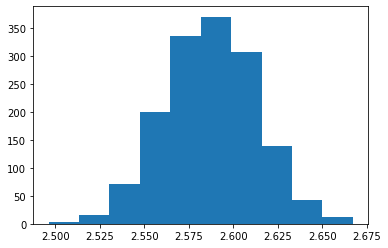

In [19]:
plt.hist(df["beta0"]/gamma)

(array([  4.,  24., 121., 224., 360., 366., 230., 116.,  50.,   5.]),
 array([0.1029955 , 0.10335911, 0.10372272, 0.10408633, 0.10444994,
        0.10481355, 0.10517716, 0.10554077, 0.10590438, 0.10626799,
        0.1066316 ]),
 <BarContainer object of 10 artists>)

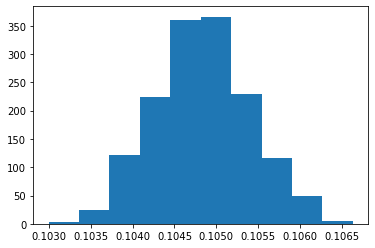

In [20]:
plt.hist(df["sigma"])

(array([  3.,  15.,  37., 166., 368., 420., 306., 142.,  35.,   8.]),
 array([0.61207986, 0.61631052, 0.62054118, 0.62477184, 0.6290025 ,
        0.63323316, 0.63746382, 0.64169448, 0.64592514, 0.6501558 ,
        0.65438646]),
 <BarContainer object of 10 artists>)

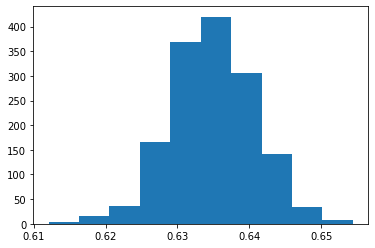

In [22]:
plt.hist(df['alpha'])

{'whiskers': [<matplotlib.lines.Line2D at 0x133fd2d90>,
 'caps': [<matplotlib.lines.Line2D at 0x133fd7f40>,
 'boxes': [<matplotlib.lines.Line2D at 0x133fd24f0>,
 'medians': [<matplotlib.lines.Line2D at 0x133fd7220>,
 'fliers': [<matplotlib.lines.Line2D at 0x133fd7580>,
 'means': []}

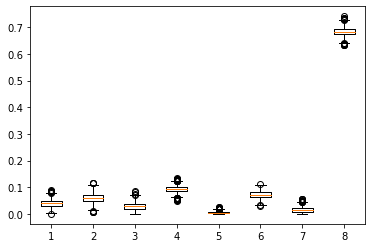

In [21]:
plt.boxplot([df["rho.1"],df["rho.2"],df["rho.3"],df["rho.4"],df["rho.5"],df["rho.6"],df["rho.7"],df["rho.8"]])

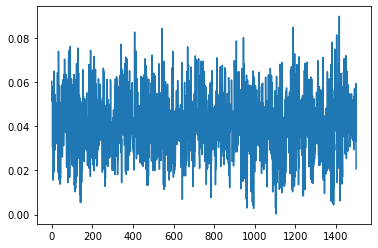

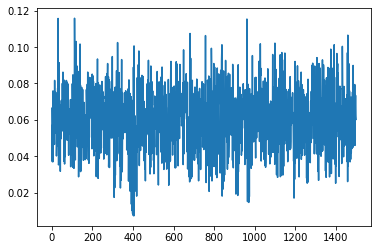

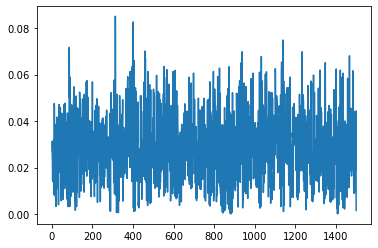

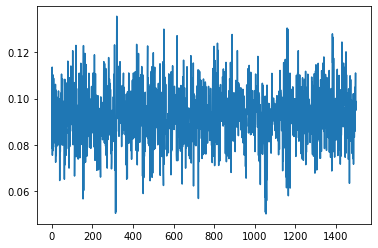

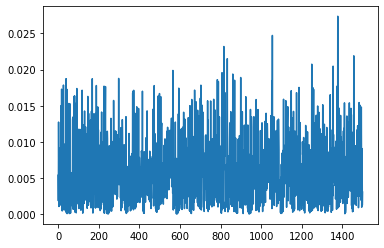

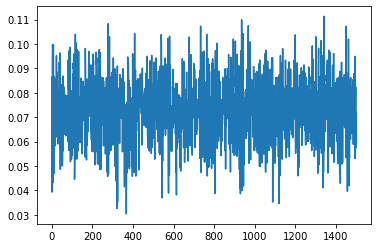

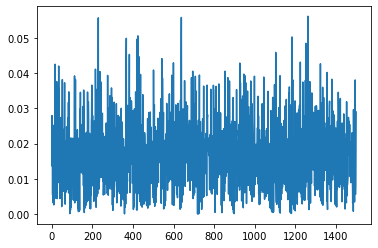

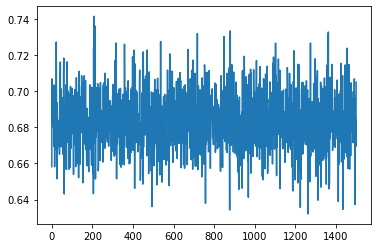

In [23]:
plt.plot(df["rho.1"]); plt.show()
plt.plot(df["rho.2"]); plt.show()
plt.plot(df["rho.3"]); plt.show()
plt.plot(df["rho.4"]); plt.show()
plt.plot(df["rho.5"]); plt.show()
plt.plot(df["rho.6"]); plt.show()
plt.plot(df["rho.7"]); plt.show()
plt.plot(df["rho.8"]); plt.show()

## covidest stan model code

In [ ]:
"""
data {
  int<lower=0> cutoff;
  int<lower=1> n_days;
  int<lower=1> days[n_days];
  int<lower=1> n_d_days;
  int<lower=1> d_days[n_d_days];
  real<lower=0> N;      // population
  int<lower=0> d[n_d_days];              // deaths
  vector<lower=0>[cutoff+1] tau_rev; // time to death distribution
  real<lower=0> ifr_min;
  real<lower=0> ifr_max;
  
  int<lower=1> n_v; // number of viral tests administered
  int<lower=1> n_s; // number of serology tests administered
  real<lower=0, upper=1> vp_hat;  // viral prevalence
  real<lower=0, upper=1> sp_hat; //seroprevalence
  int T1;  // start of phase 1 testing
  int T2;  // end of phase 1 testing
  
  int<lower=0> n_per;
  int<lower=0> n_test_days;
  int<lower=0> test_days[n_test_days];
  vector<lower=0>[n_per] cc;
  vector<lower=0>[n_per+1] tests;
  int<lower=0> per_ends[n_per+1];
}
parameters {
  real<lower=5.5, upper = 11.5> gamma_inv;
  real<lower=0> beta[n_days];
  real sigma_tilde;
  real<lower=ifr_min,upper=ifr_max> ifr;
  real y0_tilde[2];
  real<lower = 0,upper=2> phi;
  real<lower = 0> sigma_phi;
}
transformed parameters{
  matrix<lower=0>[n_days+1, 3] y;
  vector<lower=0>[n_days] nu;
  real<lower=0,upper=1> sigma = Phi(sigma_tilde);
  real<lower=0, upper=1> vp;
  real<lower=0,upper=1> sp;
  real<lower=0> vp_se;
  real<lower=0> sp_se;
  real<lower=1.0/11.5,upper=1.0/5.5> gamma = 1/gamma_inv;
  real<lower=0> death_par[n_days];
  vector<lower=0>[n_per] cc_mean;
  vector<lower=0>[n_per] cc_sd;
  {
    y[1,1] = N*0.99 + 0.01*N*Phi(y0_tilde[1]);
    y[1,2] = 0.01*N*(1-Phi(y0_tilde[1]))*Phi(y0_tilde[2]);
    y[1,3] = N - y[1,1] - y[1,2];
    for(t in 1:n_days){
      y[t+1,1] = y[t,1] * (1 - beta[t] * y[t,2] / N);
      y[t+1,2] = y[t,2] * (1 + beta[t] * y[t,1] / N - gamma);
      y[t+1,3] = y[t,3] + gamma * y[t,2];
      nu[t] = y[t,1] - y[t+1,1];
      if(t <= cutoff){
      death_par[t]=ifr*sum(tau_rev[(cutoff-t+2):(cutoff+1)] .*nu[1:t])+ifr*sum(tau_rev[1:(cutoff-t+1)])*(y[1,2]+y[1,3]);
      }else{
      death_par[t]=ifr*sum(tau_rev .*nu[(t-cutoff):t]);
      }
    }
  }
  
  for(t in 1:n_per){
    cc_mean[t] = phi*(sqrt(sum(tests[1:(t+1)])/N) * (N-y[per_ends[t+1]+1,1]) - sqrt(sum(tests[1:t])/N) * (N-y[per_ends[t]+1,1]));
    cc_sd[t] = sigma_phi * sqrt(tests[t+1]/N);
  }

  vp = mean(y[(T1+1):(T2+1),2])/N;
  vp_se = sqrt(vp*(1-vp)/n_v);
  
  sp = mean(y[(T1+1):(T2+1),3])/N;
  sp_se = sqrt(sp*(1-sp)/n_s);
}
model {
  //priors
  beta[1] ~ uniform(0,1);
  beta[2:n_days] ~ normal(beta[1:(n_days-1)], sigma);
  gamma_inv ~ normal(8.5, 1.5) T[5.5,11.5];
  sigma_tilde ~ normal(0,1);
  ifr ~ uniform(ifr_min,ifr_max);
  y0_tilde ~ normal(0,1);
  phi ~ uniform(0,2);
  sigma_phi ~ uniform(0,3);
  
  //likelihoods
  d ~ poisson(death_par[1:n_d_days]);
  vp_hat ~ normal(vp,vp_se) T[0,1];
  sp_hat ~ normal(sp,sp_se) T[0,1];
  100*cc/N ~ normal(100/N * cc_mean, cc_sd);
}"""

# Linear mixed models

In [192]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tools.sm_exceptions import ConvergenceWarning

In [193]:
t = 366 # days to model
lag = 28
window = 14
ifr = 0.007
gamma = 0.15

trunc = 10 #10
tf = 731
p = 12
s = len(states)

In [194]:
num_states = 51

# stack data matrices
# for count,state in enumerate(states[31:(31+num_states)]):
for count,state in enumerate(states):
    
    n = get_state_pop(pops,state)
    state_data = get_state_data(data,state)
    u, _ = clean_npis(state_data,tf)
    d = clean_deaths(state_data,tf)
    
    # get trajectory of infections
    i = np.convolve(d/ifr,np.ones(window)/(window),mode='same')[(lag-1):(t+lag-1)]
    
    # estimate betas
    betas, _ = beta_solve(gamma,i,t,n)
    
    # run linear regression and calculate R^2
    X_tmp = u[0:(t-1),]
    inds = np.logical_and(0<betas,betas<trunc*gamma)
    y_tmp = betas[inds]
    X_tmp = X_tmp[inds,]
    
    if count == 0:
        X = X_tmp
        y = y_tmp
        days = np.array(sum(inds)).reshape((1,1))
    else:
        X = np.concatenate([X,X_tmp])
        y = np.concatenate([y,y_tmp])
        days = np.concatenate([days,np.array(sum(inds)).reshape((1,1))])

In [195]:
print(np.shape(X));
print(np.shape(y));
ts = np.cumsum(np.concatenate([np.array(0).reshape((1,1)),days])); print(ts)

(15637, 12)
(15637,)
[    0   252   558   870  1183  1518  1834  2141  2440  2743  3073  3395
  3637  3946  4242  4562  4884  5199  5521  5845  6161  6480  6758  7078
  7394  7707  8024  8300  8613  8905  9196  9495  9818 10131 10447 10766
 11088 11406 11723 12044 12360 12681 12985 13303 13623 13929 14250 14438
 14772 15091 15389 15637]


In [197]:
# stack data matrices
for count,state in enumerate(states):
    state_id_tmp = count*np.ones(ts[count+1]-ts[count])
    
    if count == 0:
        state_id = state_id_tmp
    else:
        state_id = np.concatenate([state_id,state_id_tmp])

In [ ]:
print(np.shape(X))
print(np.shape(y))
print(np.shape(state_id))

#y = y.reshape([np.shape(y)[0],1])
#print(np.shape(y))

state_id = state_id.reshape([np.shape(state_id)[0],1])
print(np.shape(state_id))

## Linear regression (additive model)

In [196]:
"""
# stack data matrices
for count,state in enumerate(states):
    
    n = get_state_pop(pops,state)
    state_data = get_state_data(data,state)
    u, p = clean_npis(state_data,tf)
    d = clean_deaths(state_data,tf)
    
    # get trajectory of infections
    i = np.convolve(d/ifr,np.ones(window)/(window),mode='same')[(lag-1):(t+lag-1)]
    
    # estimate betas
    betas, s = beta_solve(gamma,i,t,n)
    
    # run linear regression and calculate R^2
    X_tmp = u[0:(t-1),]
    inds = np.logical_and(0<betas,betas<trunc*gamma)
    y_tmp = betas[inds]
    X_tmp = X_tmp[inds,]
    state_id_tmp = count*np.ones(np.shape(y_tmp)[0])
    
    if count == 0:
        X = X_tmp
        y = y_tmp
        state_id = state_id_tmp
    else:
        X = np.concatenate([X,X_tmp])
        y = np.concatenate([y,y_tmp])
        state_id = np.concatenate([state_id,state_id_tmp])
        
print(np.shape(X))
print(np.shape(y))
print(np.shape(state_id))

y = y.reshape([np.shape(y)[0],1])
print(np.shape(y))

state_id = state_id.reshape([np.shape(state_id)[0],1])
print(np.shape(y))
"""

"\n# stack data matrices\nfor count,state in enumerate(states):\n    \n    n = get_state_pop(pops,state)\n    state_data = get_state_data(data,state)\n    u, p = clean_npis(state_data,tf)\n    d = clean_deaths(state_data,tf)\n    \n    # get trajectory of infections\n    i = np.convolve(d/ifr,np.ones(window)/(window),mode='same')[(lag-1):(t+lag-1)]\n    \n    # estimate betas\n    betas, s = beta_solve(gamma,i,t,n)\n    \n    # run linear regression and calculate R^2\n    X_tmp = u[0:(t-1),]\n    inds = np.logical_and(0<betas,betas<trunc*gamma)\n    y_tmp = betas[inds]\n    X_tmp = X_tmp[inds,]\n    state_id_tmp = count*np.ones(np.shape(y_tmp)[0])\n    \n    if count == 0:\n        X = X_tmp\n        y = y_tmp\n        state_id = state_id_tmp\n    else:\n        X = np.concatenate([X,X_tmp])\n        y = np.concatenate([y,y_tmp])\n        state_id = np.concatenate([state_id,state_id_tmp])\n        \nprint(np.shape(X))\nprint(np.shape(y))\nprint(np.shape(state_id))\n\ny = y.reshape([np.

In [199]:
y_lmm = y.reshape([np.shape(y)[0],1])
print(np.shape(y_lmm))

lmm_data = np.concatenate([y_lmm,X,state_id],axis=1)
lmm_data = pd.DataFrame(lmm_data, columns = ['y','x1','x2','x3','x4','x5','x6','x7','x8',
                                             'x9','x10','x11','x12','id'])

# run regression
md = smf.mixedlm("y~x1+x2+x3+x4+x5+x6+x7+x8+x9+x10+x11+x12", 
                 lmm_data, groups=lmm_data["id"], re_formula="~x1+x2+x3+x4+x5+x6+x7+x8+x9+x10+x11+x12")
mdf = md.fit(method=["lbfgs"])
#mdf = md.fit()
print(mdf.summary())

(15637, 1)


/Users/njirons/opt/anaconda3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


          Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: y         
No. Observations:   15637   Method:             REML      
No. Groups:         51      Scale:              0.0104    
Min. group size:    188     Log-Likelihood:     12880.2804
Max. group size:    335     Converged:          Yes       
Mean group size:    306.6                                 
----------------------------------------------------------
                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept        0.386    0.019 20.141 0.000  0.348  0.423
x1              -0.013    0.010 -1.248 0.212 -0.033  0.007
x2              -0.023    0.012 -1.909 0.056 -0.046  0.001
x3              -0.009    0.012 -0.734 0.463 -0.032  0.015
x4              -0.030    0.013 -2.323 0.020 -0.056 -0.005
x5              -0.008    0.011 -0.744 0.457 -0.030  0.013
x6               0.005    0.014  0.323 0.746 -0.023  0.032
x7      

/Users/njirons/opt/anaconda3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [370]:
# try without x8, international travel
md = smf.mixedlm("y~x1+x2+x3+x4+x5+x6+x7+x9+x10+x11+x12", 
                 lmm_data, groups=lmm_data["id"], re_formula="~x1+x2+x3+x4+x5+x6+x7+x9+x10+x11+x12")
mdf = md.fit(method=["lbfgs"])
#mdf = md.fit()
print(mdf.summary())

/Users/njirons/opt/anaconda3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


          Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: y         
No. Observations:   15637   Method:             REML      
No. Groups:         51      Scale:              0.0107    
Min. group size:    188     Log-Likelihood:     12667.6905
Max. group size:    335     Converged:          Yes       
Mean group size:    306.6                                 
----------------------------------------------------------
                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept        0.390    0.024 16.125 0.000  0.342  0.437
x1              -0.017    0.014 -1.200 0.230 -0.044  0.010
x2              -0.026    0.013 -1.987 0.047 -0.051 -0.000
x3              -0.014    0.012 -1.234 0.217 -0.037  0.009
x4              -0.031    0.013 -2.316 0.021 -0.057 -0.005
x5              -0.007    0.012 -0.579 0.562 -0.030  0.016
x6               0.002    0.015  0.133 0.894 -0.027  0.031
x7      

/Users/njirons/opt/anaconda3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [371]:
count = 0

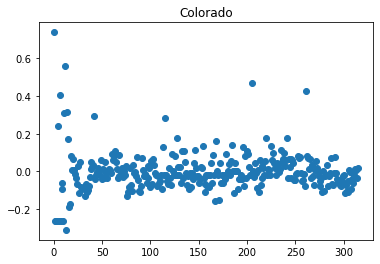

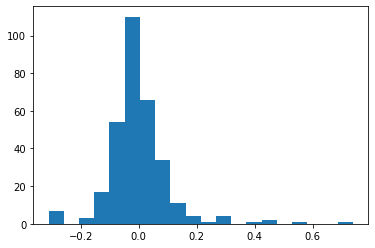

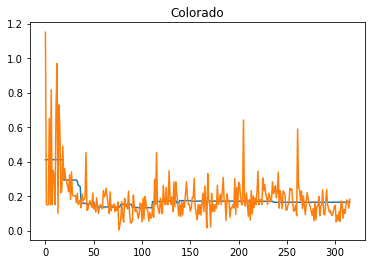

In [377]:
plt.scatter(range(np.sum(state_id[:,0] == count)),mdf.resid[state_id[:,0] == count])
plt.title(states[count])
plt.show()

plt.hist(mdf.resid[state_id[:,0] == count], bins=20)
plt.show()

plt.plot(range(np.sum(state_id[:,0] == count)),mdf.fittedvalues[state_id[:,0] == count])
plt.plot(y_lmm[state_id[:,0] == count])
plt.title(states[count])
plt.show

count += 1

## Log regression (multiplicative model)

In [ ]:
"""
# stack data matrices
for count,state in enumerate(states):
    
    n = get_state_pop(pops,state)
    state_data = get_state_data(data,state)
    u, p = clean_npis(state_data,tf)
    d = clean_deaths(state_data,tf)
    
    # get trajectory of infections
    i = np.convolve(d/ifr,np.ones(window)/(window),mode='same')[(lag-1):(t+lag-1)]
    
    # estimate betas
    betas, s = beta_solve(gamma,i,t,n)
    
    # form data matrices
    X_tmp = u[0:(t-1),]
    inds = np.logical_and(0<betas,betas<trunc*gamma)
    y_tmp = betas[inds]
    X_tmp = X_tmp[inds,]
    y_tmp = np.log(y_tmp)
    
    state_id_tmp = count*np.ones(np.shape(y_tmp)[0])
    
    if count == 0:
        X = X_tmp
        y = y_tmp
        state_id = state_id_tmp
    else:
        X = np.concatenate([X,X_tmp])
        y = np.concatenate([y,y_tmp])
        state_id = np.concatenate([state_id,state_id_tmp])
        
print(np.shape(X))
print(np.shape(y))
print(np.shape(state_id))

y = y.reshape([np.shape(y)[0],1])
print(np.shape(y))

state_id = state_id.reshape([np.shape(state_id)[0],1])
print(np.shape(y))

lmm_data = np.concatenate([y,X,state_id],axis=1)
df = pd.DataFrame(lmm_data, columns = ['y','x1','x2','x3','x4','x5','x6','x7','x8','id'])
df
"""

In [293]:
y_log = np.log(y.reshape([np.shape(y)[0],1]))
log_data = np.concatenate([y_log,X,state_id],axis=1)
log_data = pd.DataFrame(log_data, 
                        columns = ['y','x1','x2','x3','x4','x5','x6','x7','x8',
                                             'x9','x10','x11','x12','id'])

# run regression
md_log = smf.mixedlm("y~x1+x2+x3+x4+x5+x6+x7+x8+x9+x10+x11+x12", log_data, 
                 groups=log_data["id"], 
                 re_formula="~x1+x2+x3+x4+x5+x6+x7+x8+x9+x10+x11+x12")
mdf_log = md_log.fit(method=["lbfgs"])
#mdf = md.fit()
print(mdf_log.summary())

           Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: y          
No. Observations:   15637   Method:             REML       
No. Groups:         51      Scale:              0.2517     
Min. group size:    188     Log-Likelihood:     -11885.2064
Max. group size:    335     Converged:          Yes        
Mean group size:    306.6                                  
-----------------------------------------------------------
                Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept       -1.169    0.039 -29.759 0.000 -1.246 -1.092
x1              -0.134    0.040  -3.320 0.001 -0.212 -0.055
x2              -0.112    0.049  -2.276 0.023 -0.208 -0.016
x3              -0.056    0.040  -1.397 0.162 -0.133  0.022
x4              -0.139    0.044  -3.122 0.002 -0.226 -0.052
x5              -0.074    0.037  -1.988 0.047 -0.148 -0.001
x6              -0.014    0.051  -0.273 0.785 -0.11

/Users/njirons/opt/anaconda3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [369]:
# try without x8, international travel restrictions
md_log = smf.mixedlm("y~x1+x2+x3+x4+x5+x6+x7+x9+x10+x11+x12", log_data, 
                 groups=log_data["id"], 
                 re_formula="~x1+x2+x3+x4+x5+x6+x7+x9+x10+x11+x12")
mdf_log = md_log.fit(method=["lbfgs"])
#mdf = md.fit()
print(mdf_log.summary())

/Users/njirons/opt/anaconda3/lib/python3.8/site-packages/statsmodels/base/model.py:566: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/njirons/opt/anaconda3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/Users/njirons/opt/anaconda3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 95.293660
  warnings.warn(msg, ConvergenceWarning)


           Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: y          
No. Observations:   15637   Method:             REML       
No. Groups:         51      Scale:              0.2530     
Min. group size:    188     Log-Likelihood:     -11931.6316
Max. group size:    335     Converged:          No         
Mean group size:    306.6                                  
-----------------------------------------------------------
                Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept       -1.223    0.047 -26.036 0.000 -1.315 -1.131
x1              -0.136    0.076  -1.798 0.072 -0.285  0.012
x2              -0.115    0.061  -1.885 0.059 -0.235  0.005
x3              -0.073    0.049  -1.470 0.142 -0.170  0.024
x4              -0.148    0.110  -1.344 0.179 -0.365  0.068
x5              -0.067    0.053  -1.256 0.209 -0.171  0.037
x6              -0.006    0.055  -0.110 0.912 -0.11

/Users/njirons/opt/anaconda3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [294]:
count = 0

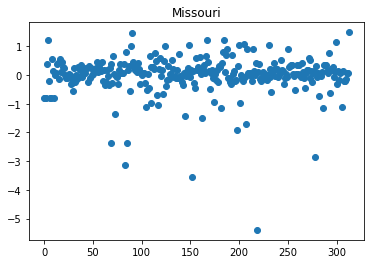

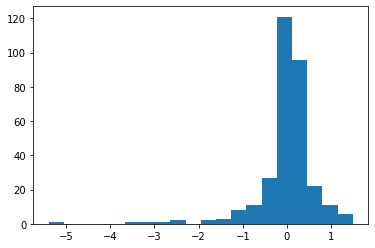

In [319]:
plt.scatter(range(np.sum(state_id[:,0] == count)),mdf_log.resid[state_id[:,0] == count])
plt.title(states[count])
plt.show()

plt.hist(mdf_log.resid[state_id[:,0] == count], bins=20)
plt.show()

count += 1

In [329]:
count = 0

35


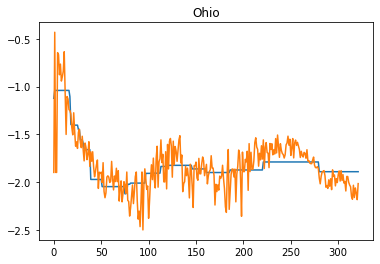

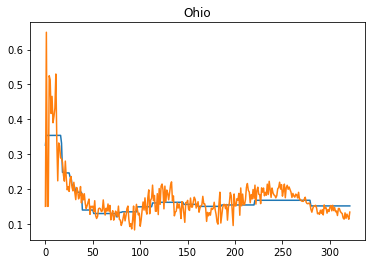

In [365]:
print(count)

plt.plot(range(np.sum(state_id[:,0] == count)),mdf_log.fittedvalues[state_id[:,0] == count])
plt.plot(y_log[state_id[:,0] == count])
plt.title(states[count])
plt.show()

plt.plot(range(np.sum(state_id[:,0] == count)),np.exp(mdf_log.fittedvalues[state_id[:,0] == count]))
plt.plot(np.exp(y_log[state_id[:,0] == count]))
plt.title(states[count])
plt.show()

count += 1

# Regression model on deaths

In [17]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tools.sm_exceptions import ConvergenceWarning

## Get data

In [6]:
t = 365 # days to model
lag = 28
window = 14
ifr = 0.007
gamma = 0.15

trunc = 10 #10
tf = 731
p = 11
s = len(states)

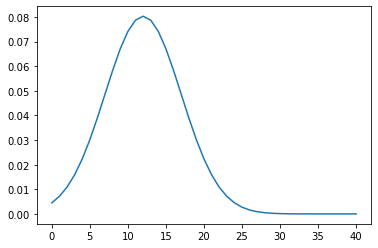

In [7]:
# Define lagged distribution
cutoff = 40
tau_rev = np.flip(norm.pdf(np.arange(0,cutoff+1), 28, 5))
tau_rev = tau_rev/np.sum(tau_rev)
plt.plot(tau_rev)

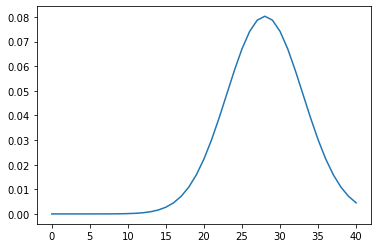

In [8]:
cutoff = 40
tau = norm.pdf(np.arange(0,cutoff+1), 28, 5)
tau = tau/np.sum(tau)
plt.plot(tau)

In [9]:
num_states = 51

# stack data matrices
# for count,state in enumerate(states[31:(31+num_states)]):
for count,state in enumerate(states):
    
    n = get_state_pop(pops,state)
    state_data = get_state_data(data,state)
    u, _ = clean_npis(state_data,tf)
    p = np.shape(u)[1]
    y_tmp = clean_deaths(state_data,tf)
    
    # smooth and account for lag from NPI -> death
    #y_tmp = np.convolve(y_tmp,np.ones(window)/(window),mode='same')[(lag-1):(t+lag-1)]
    
    # account for lag
    #y_tmp = y_tmp[(lag-1):(t+lag-1)]
    #y_tmp = y_tmp[lag:(t+lag)]
    y_tmp = y_tmp[0:t]
    
    # run linear regression and calculate R^2
    #X_tmp = u[0:(t-1),]
    X_tmp = u[0:t,]
    for j in range(p):
        # lagged covariates
        #X_tmp[:,j] = np.convolve(X_tmp[:,j],np.ones(window)/(window),mode='same')
        X_tmp[:,j] = np.convolve(X_tmp[:,j],tau,mode='same')
    
    # smooth NPIs
    
    if count == 0:
        X = X_tmp
        y = y_tmp
        days = np.array(t).reshape((1,1))
    else:
        X = np.concatenate([X,X_tmp])
        y = np.concatenate([y,y_tmp])
        days = np.concatenate([days,np.array(t).reshape((1,1))])   

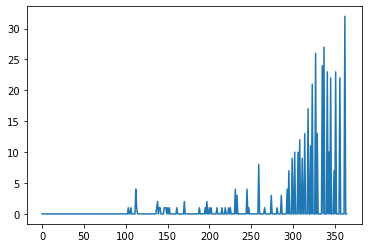

In [10]:
plt.plot(y_tmp)  

In [11]:
print(np.shape(X));
print(np.shape(y));
ts = np.cumsum(np.concatenate([np.array(0).reshape((1,1)),days])); print(ts) 

print((sum(np.isnan(y))));
print((sum(sum(np.isnan(X)))));

(18615, 12)
(18615,)
[    0   365   730  1095  1460  1825  2190  2555  2920  3285  3650  4015
  4380  4745  5110  5475  5840  6205  6570  6935  7300  7665  8030  8395
  8760  9125  9490  9855 10220 10585 10950 11315 11680 12045 12410 12775
 13140 13505 13870 14235 14600 14965 15330 15695 16060 16425 16790 17155
 17520 17885 18250 18615]
0
0


In [12]:
# stack data matrices
for count,state in enumerate(states):
    state_id_tmp = count*np.ones(ts[count+1]-ts[count])
    
    if count == 0:
        state_id = state_id_tmp
    else:
        state_id = np.concatenate([state_id,state_id_tmp])  

In [13]:
print(np.shape(X))
print(np.shape(y))
print(np.shape(state_id))

#y = y.reshape([np.shape(y)[0],1])
#print(np.shape(y))

state_id = state_id.reshape([np.shape(state_id)[0],1])
print(np.shape(state_id))

(18615, 12)
(18615,)
(18615,)
(18615, 1)


## Linear regression

In [16]:
y_lmm = y.reshape([np.shape(y)[0],1])
print(np.shape(y_lmm))

lmm_data = np.concatenate([y_lmm,X,state_id],axis=1)
lmm_data = pd.DataFrame(lmm_data, columns = ['y','x1','x2','x3','x4','x5','x6','x7','x8',
                                             'x9','x10','x11','x12','id'])

# run regression
md = smf.mixedlm(#"y~x1+x2+x3+x4+x5+x6+x7+x8+x9+x10+x11+x12", # remove int'l travel control
                 "y~x1+x2+x3+x4+x5+x6+x7+x9+x10+x11+x12",
                 lmm_data, groups=lmm_data["id"], 
                 # re_formula="~x1+x2+x3+x4+x5+x6+x7+x8+x9+x10+x11+x12")
                 re_formula="~x1+x2+x3+x4+x5+x6+x7+x9+x10+x11+x12")
mdf = md.fit(method=["lbfgs"])
#mdf = md.fit()
print(mdf.summary())

(18615, 1)
            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  y          
No. Observations:    18615    Method:              REML       
No. Groups:          51       Scale:               484.6533   
Min. group size:     365      Log-Likelihood:      -85029.2705
Max. group size:     365      Converged:           Yes        
Mean group size:     365.0                                    
--------------------------------------------------------------
                  Coef.   Std.Err.   z    P>|z|  [0.025 0.975]
--------------------------------------------------------------
Intercept           0.815   25.319  0.032 0.974 -48.810 50.440
x1                 -7.192    8.618 -0.835 0.404 -24.082  9.698
x2                -10.134    9.162 -1.106 0.269 -28.091  7.823
x3                 -8.650    9.514 -0.909 0.363 -27.297  9.998
x4                 44.929   12.112  3.709 0.000  21.189 68.669
x5                -11.965   16.378 -0.731 0.465 -44.066 2

/Users/njirons/opt/anaconda3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [18]:
count = 0

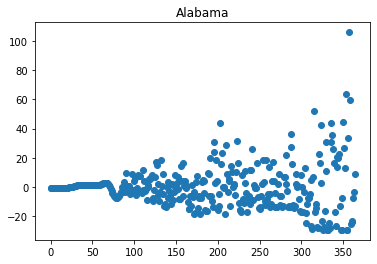

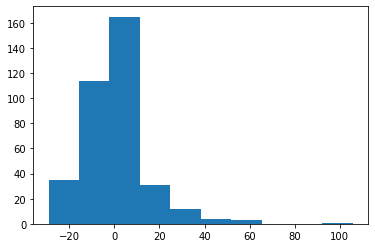

In [20]:
#plt.plot(mdf.resid[state_id[:,0] == count])
plt.scatter(range(np.sum(state_id[:,0] == count)),mdf.resid[state_id[:,0] == count])
plt.title(states[count])
plt.show()

plt.hist(mdf.resid[state_id[:,0] == count])
plt.show()

count += 1

In [183]:
count = 0

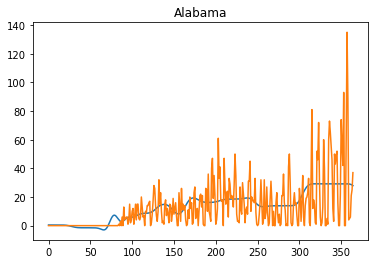

In [185]:
plt.plot(range(np.sum(state_id[:,0] == count)),mdf.fittedvalues[state_id[:,0] == count])
plt.plot(y_lmm[state_id[:,0] == count])
plt.title(states[count])
count += 1

## Log regression

In [186]:
X_log = X[y>0,]
y_log = np.log(y[y > 0,])
y_log = y_log.reshape([np.shape(y_log)[0],1])
state_id_log = state_id[y>0,]

log_data = np.concatenate([y_log,X_log,state_id_log],axis=1)
log_data = pd.DataFrame(log_data, 
                        columns = ['y','x1','x2','x3','x4','x5','x6','x7','x8',
                                             'x9','x10','x11','x12','id'])

# run regression
md_log = smf.mixedlm(#"y~x1+x2+x3+x4+x5+x6+x7+x8+x9+x10+x11+x12", # remove int'l travel control
    "y~x1+x2+x3+x4+x5+x6+x7+x9+x10+x11+x12",
    log_data, groups=log_data["id"],
    #re_formula="~x1+x2+x3+x4+x5+x6+x7+x8+x9+x10+x11+x12")
    re_formula="~x1+x2+x3+x4+x5+x6+x7+x9+x10+x11+x12")
mdf_log = md_log.fit(method=["lbfgs"])
#mdf = md.fit()
print(mdf_log.summary())

          Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: y          
No. Observations:  12101   Method:             REML       
No. Groups:        51      Scale:              0.5214     
Min. group size:   56      Log-Likelihood:     -13921.3497
Max. group size:   296     Converged:          Yes        
Mean group size:   237.3                                  
----------------------------------------------------------
                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept        0.180    0.425  0.423 0.673 -0.653  1.012
x1              -0.517    0.217 -2.380 0.017 -0.942 -0.091
x2              -0.039    0.296 -0.131 0.896 -0.619  0.541
x3               0.017    0.204  0.084 0.933 -0.384  0.418
x4               1.567    0.315  4.973 0.000  0.950  2.185
x5               0.176    0.222  0.793 0.428 -0.259  0.611
x6               0.415    0.215  1.929 0.054 -0.007  0.837
x7      

In [187]:
count = 0

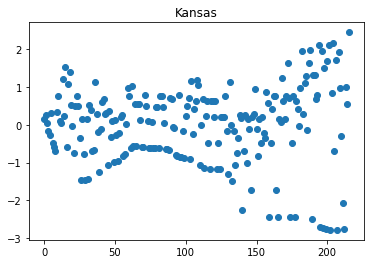

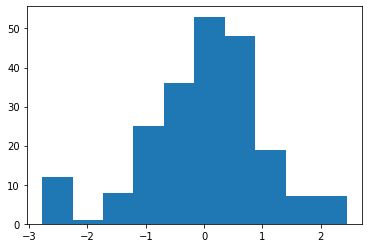

In [204]:
#plt.plot(mdf_log.resid[state_id_log[:,0] == count])
plt.scatter(range(np.sum(state_id_log[:,0] == count)),mdf_log.resid[state_id_log[:,0] == count])
plt.title(states[count])
plt.show()

plt.hist(mdf_log.resid[state_id_log[:,0] == count])
plt.show()

count += 1

In [205]:
count = 0

IndexError: index 51 is out of bounds for axis 0 with size 51

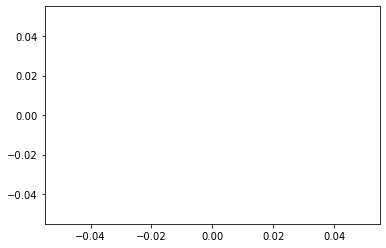

In [257]:
plt.plot(range(np.sum(state_id_log[:,0] == count)),mdf_log.fittedvalues[state_id_log[:,0] == count])
plt.plot(y_log[state_id_log[:,0] == count])
plt.title(states[count])
plt.show()

plt.plot(range(np.sum(state_id_log[:,0] == count)),np.exp(mdf_log.fittedvalues[state_id_log[:,0] == count]))
plt.plot(np.exp(y_log[state_id_log[:,0] == count]))
plt.title(states[count])
plt.show()
count += 1

## Poisson GLMM

In [136]:
import statsmodels.genmod.bayes_mixed_glm as bm_glm

In [ ]:
y_lmm = y.reshape([np.shape(y)[0],1])
print(np.shape(y_lmm))

lmm_data = np.concatenate([y_lmm,X,state_id],axis=1)
lmm_data = pd.DataFrame(lmm_data, columns = ['y','x1','x2','x3','x4','x5','x6','x7','x8',
                                             'x9','x10','x11','x12','id'])

# run regression
md = smf.mixedlm(#"y~x1+x2+x3+x4+x5+x6+x7+x8+x9+x10+x11+x12", # remove int'l travel control
                 "y~x1+x2+x3+x4+x5+x6+x7+x9+x10+x11+x12",
                 lmm_data, groups=lmm_data["id"], 
                 # re_formula="~x1+x2+x3+x4+x5+x6+x7+x8+x9+x10+x11+x12")
                 re_formula="~x1+x2+x3+x4+x5+x6+x7+x9+x10+x11+x12")
mdf = md.fit(method=["lbfgs"])
#mdf = md.fit()
print(mdf.summary())

In [138]:
pglm_md = bm_glm.PoissonBayesMixedGLM.from_formula(
                "y~x1+x2+x3+x4+x5+x6+x7+x9+x10+x11+x12", "~x1+x2+x3+x4+x5+x6+x7+x9+x10+x11+x12", lmm_data,)


AttributeError: 'str' object has no attribute 'items'

## Negative Binomial GLM

In [143]:
data.exog = sm.add_constant(X)
data.endog = y_lmm

# Instantiate a gamma family model with the default link function.
negbin_md = sm.GLM(data.endog, data.exog, family=sm.families.NegativeBinomial())

In [144]:
negbin_results = negbin_md.fit()

print(negbin_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                18615
Model:                            GLM   Df Residuals:                    18602
Model Family:        NegativeBinomial   Df Model:                           12
Link Function:                    log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -58957.
Date:                Tue, 03 May 2022   Deviance:                       33370.
Time:                        11:39:10   Pearson chi2:                 6.73e+04
No. Iterations:                    18                                         
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.0992      0.269    -22.661      0.0

In [146]:
count = 0

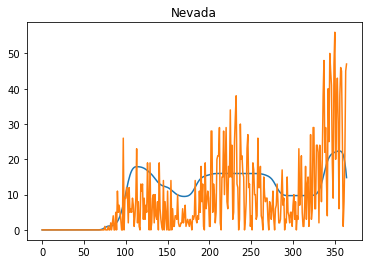

In [182]:
plt.plot(range(np.sum(state_id[:,0] == count)),negbin_results.fittedvalues[state_id[:,0] == count])
plt.plot(y_lmm[state_id[:,0] == count])
plt.title(states[count])
plt.show()

count+=1